In [2]:
from pathlib import Path
import pandas as pd

project_root = Path("/home/dwp46550/ba_nylon")

df = pd.read_csv(
    project_root / "matrices" / "NylC_Puetz_raw_data.CSV",
    sep=";",
    decimal=","
)
print(df.shape)

(36, 7)


### Build mutation-based sequence features for experimentally characterized variants

This cell loads the wild-type NylC reference sequence and all known variant FASTA files. Each variant sequence is compared against the wild-type sequence to extract amino acid substitutions in standard mutation notation, for example `D304M` or `F134W`.

For every variant, the code computes mutation-level descriptors such as the number of mutations, changes in charge, hydrophobicity, and side-chain volume. It also classifies mutated positions into literature-supported positions, MD-contact positions, and unknown positions. Finally, mutation identities and mutated positions are one-hot encoded so that the variants can be used as input for machine learning models.

In [ ]:
from pathlib import Path
import re
import pandas as pd
from Bio import SeqIO
from sklearn.preprocessing import MultiLabelBinarizer


project_root = Path("/home/dwp46550/ba_nylon")
known_fasta_dir = project_root / "inputs" / "variant_fastas"
reference_fasta = known_fasta_dir / "WT.fasta"


def read_fasta_sequence(path):
    record = next(SeqIO.parse(path, "fasta"))
    return str(record.seq)


reference_seq = read_fasta_sequence(reference_fasta)

#woher?
aa_properties = {
    "A": {"charge": 0, "hydrophobicity": 1.8, "volume": 88.6},
    "R": {"charge": 1, "hydrophobicity": -4.5, "volume": 173.4},
    "N": {"charge": 0, "hydrophobicity": -3.5, "volume": 114.1},
    "D": {"charge": -1, "hydrophobicity": -3.5, "volume": 111.1},
    "C": {"charge": 0, "hydrophobicity": 2.5, "volume": 108.5},
    "Q": {"charge": 0, "hydrophobicity": -3.5, "volume": 143.8},
    "E": {"charge": -1, "hydrophobicity": -3.5, "volume": 138.4},
    "G": {"charge": 0, "hydrophobicity": -0.4, "volume": 60.1},
    "H": {"charge": 0.5, "hydrophobicity": -3.2, "volume": 153.2},
    "I": {"charge": 0, "hydrophobicity": 4.5, "volume": 166.7},
    "L": {"charge": 0, "hydrophobicity": 3.8, "volume": 166.7},
    "K": {"charge": 1, "hydrophobicity": -3.9, "volume": 168.6},
    "M": {"charge": 0, "hydrophobicity": 1.9, "volume": 162.9},
    "F": {"charge": 0, "hydrophobicity": 2.8, "volume": 189.9},
    "P": {"charge": 0, "hydrophobicity": -1.6, "volume": 112.7},
    "S": {"charge": 0, "hydrophobicity": -0.8, "volume": 89.0},
    "T": {"charge": 0, "hydrophobicity": -0.7, "volume": 116.1},
    "W": {"charge": 0, "hydrophobicity": -0.9, "volume": 227.8},
    "Y": {"charge": 0, "hydrophobicity": -1.3, "volume": 193.6},
    "V": {"charge": 0, "hydrophobicity": 4.2, "volume": 140.0},
}

#woher?
aa_group = {
    "G": "small_special",
    "A": "small_special",
    "P": "small_special",

    "S": "polar_uncharged",
    "T": "polar_uncharged",
    "N": "polar_uncharged",
    "Q": "polar_uncharged",
    "C": "polar_uncharged",

    "I": "hydrophobic_aliphatic",
    "L": "hydrophobic_aliphatic",
    "V": "hydrophobic_aliphatic",
    "M": "hydrophobic_aliphatic",

    "F": "aromatic",
    "W": "aromatic",
    "Y": "aromatic",

    "K": "positive",
    "R": "positive",
    "H": "positive",

    "D": "negative",
    "E": "negative",
}


aa_group_id = {
    "small_special": 0,
    "polar_uncharged": 1,
    "hydrophobic_aliphatic": 2,
    "aromatic": 3,
    "positive": 4,
    "negative": 5,
}


known_positions = {99, 134, 301, 304, 330}
md_contact_positions = {91, 98, 111, 137, 139, 144, 146, 305}
key_positions = {99, 134, 301, 304, 330} #redundant


def extract_mutations(reference_seq, variant_seq):
    if len(reference_seq) != len(variant_seq):
        raise ValueError(
            f"Sequence length mismatch: reference={len(reference_seq)}, variant={len(variant_seq)}"
        )

    mutations = []

    for pos, (wt_aa, var_aa) in enumerate(zip(reference_seq, variant_seq), start=1):
        if wt_aa != var_aa:
            mutations.append(f"{wt_aa}{pos}{var_aa}")

    return mutations


def parse_mutation_string(mutation_string):
    if pd.isna(mutation_string) or str(mutation_string).strip() == "":
        return []

    return [
        m.strip()
        for m in re.split(r"[;,]", str(mutation_string))
        if m.strip()
    ]


def mutation_position(mutation):
    match = re.search(r"\d+", mutation)

    if match is None:
        raise ValueError(f"Could not parse mutation position from: {mutation}")

    return int(match.group())


def mutation_delta(mutation, property_name):
    wt_aa = mutation[0]
    new_aa = mutation[-1]

    if wt_aa not in aa_properties:
        raise ValueError(f"Unknown wild type amino acid in mutation: {mutation}")

    if new_aa not in aa_properties:
        raise ValueError(f"Unknown mutant amino acid in mutation: {mutation}")

    return aa_properties[new_aa][property_name] - aa_properties[wt_aa][property_name]


def mutation_group_transition(mutation):
    wt_aa = mutation[0]
    new_aa = mutation[-1]

    if wt_aa not in aa_group:
        raise ValueError(f"Unknown wild type amino acid in mutation: {mutation}")

    if new_aa not in aa_group:
        raise ValueError(f"Unknown mutant amino acid in mutation: {mutation}")

    wt_group = aa_group[wt_aa]
    new_group = aa_group[new_aa]

    return {
        "wt_group": wt_group,
        "new_group": new_group,
        "wt_group_id": aa_group_id[wt_group],
        "new_group_id": aa_group_id[new_group],
        "group_changed": int(wt_group != new_group),
        "transition": f"{wt_group}_to_{new_group}",
    }


def build_features_from_mutation_list(variant, mutations, sequence=None):
    mutation_set = set(mutations)
    positions = [mutation_position(m) for m in mutations]

    delta_charge = 0
    delta_hydrophobicity = 0
    delta_volume = 0

    n_known_position_mut = 0
    n_md_contact_mut = 0
    n_unknown_position_mut = 0

    n_group_changed = 0
    n_to_hydrophobic = 0
    n_to_aromatic = 0
    n_to_positive = 0
    n_to_negative = 0
    n_from_charged = 0
    n_charge_gain = 0
    n_charge_loss = 0

    group_transition_list = []

    position_specific_features = {}

    for pos in key_positions:
        position_specific_features[f"delta_charge_pos_{pos}"] = 0
        position_specific_features[f"delta_hydrophobicity_pos_{pos}"] = 0
        position_specific_features[f"delta_volume_pos_{pos}"] = 0

        position_specific_features[f"aa_group_from_pos_{pos}"] = -1
        position_specific_features[f"aa_group_to_pos_{pos}"] = -1
        position_specific_features[f"aa_group_changed_pos_{pos}"] = 0

        position_specific_features[f"pos_{pos}_to_hydrophobic"] = 0
        position_specific_features[f"pos_{pos}_to_aromatic"] = 0
        position_specific_features[f"pos_{pos}_to_positive"] = 0
        position_specific_features[f"pos_{pos}_to_negative"] = 0

    for mutation in mutations:
        pos = mutation_position(mutation)

        d_charge = mutation_delta(mutation, "charge")
        d_hydrophobicity = mutation_delta(mutation, "hydrophobicity")
        d_volume = mutation_delta(mutation, "volume")

        group_info = mutation_group_transition(mutation)

        delta_charge += d_charge
        delta_hydrophobicity += d_hydrophobicity
        delta_volume += d_volume

        n_group_changed += group_info["group_changed"]
        group_transition_list.append(group_info["transition"])

        if group_info["new_group"] == "hydrophobic_aliphatic":
            n_to_hydrophobic += 1

        if group_info["new_group"] == "aromatic":
            n_to_aromatic += 1

        if group_info["new_group"] == "positive":
            n_to_positive += 1

        if group_info["new_group"] == "negative":
            n_to_negative += 1

        if group_info["wt_group"] in {"positive", "negative"}:
            n_from_charged += 1

        if d_charge > 0:
            n_charge_gain += 1

        if d_charge < 0:
            n_charge_loss += 1

        if pos in known_positions:
            n_known_position_mut += 1
        elif pos in md_contact_positions:
            n_md_contact_mut += 1
        else:
            n_unknown_position_mut += 1

        if pos in key_positions:
            position_specific_features[f"delta_charge_pos_{pos}"] = d_charge
            position_specific_features[f"delta_hydrophobicity_pos_{pos}"] = d_hydrophobicity
            position_specific_features[f"delta_volume_pos_{pos}"] = d_volume

            position_specific_features[f"aa_group_from_pos_{pos}"] = group_info["wt_group_id"]
            position_specific_features[f"aa_group_to_pos_{pos}"] = group_info["new_group_id"]
            position_specific_features[f"aa_group_changed_pos_{pos}"] = group_info["group_changed"]

            position_specific_features[f"pos_{pos}_to_hydrophobic"] = int(
                group_info["new_group"] == "hydrophobic_aliphatic"
            )
            position_specific_features[f"pos_{pos}_to_aromatic"] = int(
                group_info["new_group"] == "aromatic"
            )
            position_specific_features[f"pos_{pos}_to_positive"] = int(
                group_info["new_group"] == "positive"
            )
            position_specific_features[f"pos_{pos}_to_negative"] = int(
                group_info["new_group"] == "negative"
            )

    has_d99r = "D99R" in mutation_set
    has_f134w = "F134W" in mutation_set
    has_d304m = "D304M" in mutation_set
    has_r330a = "R330A" in mutation_set
    has_r330q = "R330Q" in mutation_set
    has_d304_any = any(mutation_position(m) == 304 for m in mutations)

    row = {
        "variant": variant,
        "mutations": ";".join(mutations),
        "mutation_list": mutations,
        "position_list": [str(pos) for pos in positions],
        "group_transition_list": group_transition_list,

        "n_mut": len(mutations),
        "delta_charge": delta_charge,
        "delta_hydrophobicity": delta_hydrophobicity,
        "delta_volume": delta_volume,

        "n_known_position_mut": n_known_position_mut,
        "n_md_contact_mut": n_md_contact_mut,
        "n_unknown_position_mut": n_unknown_position_mut,

        "n_aa_group_changed": n_group_changed,
        "n_to_hydrophobic": n_to_hydrophobic,
        "n_to_aromatic": n_to_aromatic,
        "n_to_positive": n_to_positive,
        "n_to_negative": n_to_negative,
        "n_from_charged": n_from_charged,
        "n_charge_gain": n_charge_gain,
        "n_charge_loss": n_charge_loss,

        "D99R_with_D304_any": int(has_d99r and has_d304_any),
        "D99R_with_HP_core": int(has_d99r and has_f134w and has_d304m and has_r330a),
        "F134W_with_D304_any": int(has_f134w and has_d304_any),
        "HP_core": int(has_f134w and has_d304m and has_r330a),
        "HP_core_with_R330Q": int(has_f134w and has_d304m and has_r330q),
    }

    if sequence is not None:
        row["sequence"] = sequence

    row.update(position_specific_features)

    return row


def add_onehot_features(base_df):
    base_df = base_df.copy()

    mlb_mut = MultiLabelBinarizer()
    mut_onehot = pd.DataFrame(
        mlb_mut.fit_transform(base_df["mutation_list"]),
        columns=[f"mut_{m}" for m in mlb_mut.classes_],
        index=base_df.index,
    )

    mlb_pos = MultiLabelBinarizer()
    pos_onehot = pd.DataFrame(
        mlb_pos.fit_transform(base_df["position_list"]),
        columns=[f"pos_{p}" for p in mlb_pos.classes_],
        index=base_df.index,
    )

    mlb_transition = MultiLabelBinarizer()
    transition_onehot = pd.DataFrame(
        mlb_transition.fit_transform(base_df["group_transition_list"]),
        columns=[f"aa_transition_{t}" for t in mlb_transition.classes_],
        index=base_df.index,
    )

    feature_df = pd.concat(
        [
            base_df.drop(
                columns=[
                    "sequence",
                    "mutation_list",
                    "position_list",
                    "group_transition_list",
                ],
                errors="ignore",
            ),
            mut_onehot,
            pos_onehot,
            transition_onehot,
        ],
        axis=1,
    )

    return feature_df


def build_sequence_feature_table(fasta_dir, reference_seq):
    rows = []

    for fasta_file in sorted(Path(fasta_dir).glob("*.fasta")):
        variant = fasta_file.stem
        sequence = read_fasta_sequence(fasta_file)
        mutations = extract_mutations(reference_seq, sequence)

        rows.append(
            build_features_from_mutation_list(
                variant=variant,
                mutations=mutations,
                sequence=sequence,
            )
        )

    base_df = pd.DataFrame(rows)

    return add_onehot_features(base_df)


known_feature_df = build_sequence_feature_table(known_fasta_dir, reference_seq)

display(known_feature_df.head())
print(known_feature_df.shape)

,variant,mutations,n_mut,delta_charge,delta_hydrophobicity,delta_volume,n_known_position_mut,n_md_contact_mut,n_unknown_position_mut,n_aa_group_changed,...,aa_transition_aromatic_to_aromatic,aa_transition_aromatic_to_hydrophobic_aliphatic,aa_transition_negative_to_aromatic,aa_transition_negative_to_hydrophobic_aliphatic,aa_transition_negative_to_negative,aa_transition_negative_to_polar_uncharged,aa_transition_negative_to_positive,aa_transition_negative_to_small_special,aa_transition_positive_to_polar_uncharged,aa_transition_positive_to_small_special
0,D304E,D304E,1,0,0.0,27.3,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,D304L,D304L,1,1,7.3,55.6,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,D304M,D304M,1,1,5.4,51.8,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,D304Q,D304Q,1,1,0.0,32.7,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,D304R,D304R,1,2,-1.0,62.3,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0


(35, 103)


In [4]:
numeric_cols = known_feature_df.select_dtypes(include="number").columns

constant_cols = [
    c for c in numeric_cols
    if known_feature_df[c].nunique(dropna=True) <= 1
]

known_feature_df = known_feature_df.drop(columns=constant_cols)

print("Dropped constant features:", constant_cols)
print("Final feature table shape:", known_feature_df.shape)

Dropped constant features: ['n_md_contact_mut', 'n_unknown_position_mut', 'pos_99_to_aromatic', 'pos_99_to_negative', 'delta_charge_pos_134', 'aa_group_changed_pos_134', 'pos_134_to_hydrophobic', 'pos_134_to_positive', 'pos_134_to_negative', 'pos_330_to_hydrophobic', 'pos_330_to_aromatic', 'pos_330_to_positive', 'pos_330_to_negative', 'delta_charge_pos_301', 'pos_301_to_aromatic', 'pos_301_to_positive', 'pos_301_to_negative']
Final feature table shape: (35, 86)


In [5]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

activity = df["activity_pa6"]
temp = df["tm_celsius"]

def feature_wise_spearman(activity, temp, feature_df):
    results = []

    skip_cols = ["variant", "mutations"]

    for feature in feature_df.columns:
        if feature in skip_cols:
            continue

        feature_values = pd.to_numeric(feature_df[feature], errors="coerce")

        tmp_activity = pd.concat(
            [
                pd.to_numeric(activity, errors="coerce").rename("activity_pa6"),
                feature_values.rename(feature)
            ],
            axis=1
        ).dropna()

        if len(tmp_activity) >= 3 and tmp_activity[feature].nunique() > 1:
            rho_activity, p_activity = spearmanr(
                tmp_activity["activity_pa6"],
                tmp_activity[feature]
            )
        else:
            rho_activity, p_activity = np.nan, np.nan

        tmp_tm = pd.concat(
            [
                pd.to_numeric(temp, errors="coerce").rename("tm_celsius"),
                feature_values.rename(feature)
            ],
            axis=1
        ).dropna()

        if len(tmp_tm) >= 3 and tmp_tm[feature].nunique() > 1:
            rho_tm, p_tm = spearmanr(
                tmp_tm["tm_celsius"],
                tmp_tm[feature]
            )
        else:
            rho_tm, p_tm = np.nan, np.nan

        results.append({
            "feature": feature,
            "spearman_activity": rho_activity,
            "p_activity": p_activity,
            "n_activity": len(tmp_activity),
            "spearman_tm": rho_tm,
            "p_tm": p_tm,
            "n_tm": len(tmp_tm)
        })

    result_df = pd.DataFrame(results)

    result_df["abs_spearman_activity"] = result_df["spearman_activity"].abs()
    result_df["abs_spearman_tm"] = result_df["spearman_tm"].abs()

    return result_df.sort_values(
        by="abs_spearman_activity",
        ascending=False
    )

In [6]:

spearman_results = feature_wise_spearman(
    activity=df["activity_pa6"],
    temp=df["tm_celsius"],
    feature_df=known_feature_df
)

print(spearman_results)
print(spearman_results.shape)

                               feature  spearman_activity  p_activity  \
9                        n_to_negative          -0.341308    0.044794   
27                 pos_304_to_negative          -0.341308    0.044794   
78  aa_transition_negative_to_negative          -0.341308    0.044794   
53                           mut_D304E          -0.341308    0.044794   
70                             pos_301           0.263241    0.126541   
..                                 ...                ...         ...   
5                   n_aa_group_changed           0.015237    0.930770   
23            aa_group_changed_pos_304          -0.008941    0.959344   
17                  HP_core_with_R330Q          -0.004447    0.979775   
2                 delta_hydrophobicity          -0.002733    0.987567   
16                             HP_core           0.000000    1.000000   

    n_activity  spearman_tm      p_tm  n_tm  abs_spearman_activity  \
9           35    -0.145986  0.425305    32          

### Train activity and thermostability prediction models

This cell merges the sequence-derived feature table with experimental labels for PA6 activity and melting temperature. The data are cleaned by converting activity and melting temperature values into numeric format.

The model uses numeric mutation features as predictors and trains two separate ElasticNet regression pipelines: one for enzymatic activity and one for thermostability. Both models use standardization followed by ElasticNetCV. Leave-one-out cross-validation is used because the experimental dataset is small. The fitted models are later used to predict activity and thermostability for BoltzGen-generated variants.

In [ ]:

#pip install tabpfn-client

Note: you may need to restart the kernel to use updated packages.


In [8]:
#to use Tabpfn create a Tabpfn token via their website first
#https://ux.priorlabs.ai
#then copy paste into your terminal
#export TABPFN_TOKEN="your API key"

In [9]:
from tabpfn import TabPFNRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import spearmanr, pearsonr
import numpy as np
import pandas as pd
import os


from dotenv import load_dotenv
import os

load_dotenv()

if "TABPFN_TOKEN" not in os.environ:
    raise RuntimeError("TABPFN_TOKEN is not set.")

lab_data = df.copy()

lab_data = lab_data.rename(columns={
    "variant_id": "variant",
    "activity_pa6": "activity",
    "tm_celsius": "tm",
})

lab_data["activity"] = pd.to_numeric(
    lab_data["activity"],
    errors="coerce"
)

lab_data["tm"] = (
    lab_data["tm"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

lab_data["tm"] = pd.to_numeric(
    lab_data["tm"],
    errors="coerce"
)


model_df = known_feature_df.merge(
    lab_data[["variant", "activity", "tm"]],
    on="variant",
    how="inner"
)

print("Merged shape:", model_df.shape)
display(model_df.head())


non_feature_cols = {
    "variant",
    "mutations",
    "sequence",
    "activity",
    "tm",
}

feature_cols = [
    c for c in model_df.columns
    if c not in non_feature_cols
    and pd.api.types.is_numeric_dtype(model_df[c])
]


constant_cols = [
    c for c in feature_cols
    if model_df[c].nunique(dropna=True) <= 1
]

feature_cols = [
    c for c in feature_cols
    if c not in constant_cols
]

print("Dropped constant features:", constant_cols)
print("Number of usable features:", len(feature_cols))
print(feature_cols)


activity_model_df = model_df.dropna(subset=["activity"]).copy()

X_activity = activity_model_df[feature_cols].fillna(0)
y_activity = activity_model_df["activity"]

activity_model_tabpfn = TabPFNRegressor()

activity_pred_loo_tabpfn = cross_val_predict(
    activity_model_tabpfn,
    X_activity,
    y_activity,
    cv=LeaveOneOut(),
    n_jobs=1
)

print("Activity LOOCV")
print("R2:", r2_score(y_activity, activity_pred_loo_tabpfn))
print("MAE:", mean_absolute_error(y_activity, activity_pred_loo_tabpfn))
print("Pearson:", pearsonr(y_activity, activity_pred_loo_tabpfn))
print("Spearman:", spearmanr(y_activity, activity_pred_loo_tabpfn))

activity_eval_tabpfn = activity_model_df[["variant", "mutations", "activity"]].copy()
activity_eval_tabpfn["pred_activity_loo_tabpfn"] = activity_pred_loo_tabpfn
activity_eval_tabpfn["abs_error_tabpfn"] = (
    activity_eval_tabpfn["activity"]
    - activity_eval_tabpfn["pred_activity_loo_tabpfn"]
).abs()

display(
    activity_eval_tabpfn
    .sort_values("abs_error_tabpfn", ascending=False)
    .head(10)
)

activity_model_tabpfn.fit(X_activity, y_activity)


tm_model_df = model_df.dropna(subset=["tm"]).copy()

X_tm = tm_model_df[feature_cols].fillna(0)
y_tm = tm_model_df["tm"]

tm_model_tabpfn = TabPFNRegressor()

tm_pred_loo_tabpfn = cross_val_predict(
    tm_model_tabpfn,
    X_tm,
    y_tm,
    cv=LeaveOneOut(),
    n_jobs=1
)

print("\nTm LOOCV")
print("R2:", r2_score(y_tm, tm_pred_loo_tabpfn))
print("MAE:", mean_absolute_error(y_tm, tm_pred_loo_tabpfn))
print("Pearson:", pearsonr(y_tm, tm_pred_loo_tabpfn))
print("Spearman:", spearmanr(y_tm, tm_pred_loo_tabpfn))

tm_eval_tabpfn = tm_model_df[["variant", "mutations", "tm"]].copy()
tm_eval_tabpfn["pred_tm_loo_tabpfn"] = tm_pred_loo_tabpfn
tm_eval_tabpfn["abs_error_tabpfn"] = (
    tm_eval_tabpfn["tm"]
    - tm_eval_tabpfn["pred_tm_loo_tabpfn"]
).abs()

display(
    tm_eval_tabpfn
    .sort_values("abs_error_tabpfn", ascending=False)
    .head(10)
)

tm_model_tabpfn.fit(X_tm, y_tm)

/rwthfs/rz/cluster/home/dwp46550/ba_nylon/envs/ba_nylc/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Merged shape: (35, 88)


,variant,mutations,n_mut,delta_charge,delta_hydrophobicity,delta_volume,n_known_position_mut,n_aa_group_changed,n_to_hydrophobic,n_to_aromatic,...,aa_transition_negative_to_aromatic,aa_transition_negative_to_hydrophobic_aliphatic,aa_transition_negative_to_negative,aa_transition_negative_to_polar_uncharged,aa_transition_negative_to_positive,aa_transition_negative_to_small_special,aa_transition_positive_to_polar_uncharged,aa_transition_positive_to_small_special,activity,tm
0,D304E,D304E,1,0,0.0,27.3,1,0,0,0,...,0,0,1,0,0,0,0,0,171,87.9
1,D304L,D304L,1,1,7.3,55.6,1,1,1,0,...,0,1,0,0,0,0,0,0,138,89.6
2,D304M,D304M,1,1,5.4,51.8,1,1,1,0,...,0,1,0,0,0,0,0,0,234,89.5
3,D304Q,D304Q,1,1,0.0,32.7,1,1,0,0,...,0,0,0,1,0,0,0,0,157,89.6
4,D304R,D304R,1,2,-1.0,62.3,1,1,0,0,...,0,0,0,0,1,0,0,0,123,88.4


Dropped constant features: []
Number of usable features: 84
['n_mut', 'delta_charge', 'delta_hydrophobicity', 'delta_volume', 'n_known_position_mut', 'n_aa_group_changed', 'n_to_hydrophobic', 'n_to_aromatic', 'n_to_positive', 'n_to_negative', 'n_from_charged', 'n_charge_gain', 'n_charge_loss', 'D99R_with_D304_any', 'D99R_with_HP_core', 'F134W_with_D304_any', 'HP_core', 'HP_core_with_R330Q', 'delta_charge_pos_304', 'delta_hydrophobicity_pos_304', 'delta_volume_pos_304', 'aa_group_from_pos_304', 'aa_group_to_pos_304', 'aa_group_changed_pos_304', 'pos_304_to_hydrophobic', 'pos_304_to_aromatic', 'pos_304_to_positive', 'pos_304_to_negative', 'delta_charge_pos_99', 'delta_hydrophobicity_pos_99', 'delta_volume_pos_99', 'aa_group_from_pos_99', 'aa_group_to_pos_99', 'aa_group_changed_pos_99', 'pos_99_to_hydrophobic', 'pos_99_to_positive', 'delta_hydrophobicity_pos_134', 'delta_volume_pos_134', 'aa_group_from_pos_134', 'aa_group_to_pos_134', 'pos_134_to_aromatic', 'delta_charge_pos_330', 'delta_

,variant,mutations,activity,pred_activity_loo_tabpfn,abs_error_tabpfn
26,F134W_D304M_R330A,F134W;D304M;R330A,520,301.004120,218.995880
16,D99R_F134W_R330A,D99R;F134W;R330A,406,275.418274,130.581726
25,F134W_D304M,F134W;D304M,410,279.690277,130.309723
30,F134W_D304V,F134W;D304V,202,317.370819,115.370819
20,D99V_F134W_D304M_R330Q,D99V;F134W;D304M;R330Q,205,303.822662,98.822662
24,F134W_D304L,F134W;D304L,371,279.179413,91.820587
18,D99V_F134W_D304M,D99V;F134W;D304M,201,292.447113,91.447113
2,D304M,D304M,234,145.308762,88.691238
19,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,391,304.345154,86.654846
34,WT,,77,163.405365,86.405365



Tm LOOCV
R2: 0.6505564225209877
MAE: 0.9622310161590577
Pearson: PearsonRResult(statistic=0.8098333853552531, pvalue=1.977379122244655e-08)
Spearman: SignificanceResult(statistic=0.8011005776995411, pvalue=3.64213809177263e-08)


,variant,mutations,tm,pred_tm_loo_tabpfn,abs_error_tabpfn
8,D99G_F134W_D304M,D99G;F134W;D304M,83.7,88.064232,4.364232
6,D304W,D304W,85.0,88.617302,3.617302
9,D99G_F134W_D304M_R330Q,D99G;F134W;D304M;R330Q,87.7,84.181854,3.518146
29,F134W_D304S,F134W;D304S,90.5,88.317856,2.182144
18,D99V_F134W_D304M,D99V;F134W;D304M,86.5,84.907516,1.592484
31,F301L,F301L,83.7,85.167404,1.467404
33,R330Q,R330Q,83.8,85.140572,1.340572
34,WT,,85.7,84.512741,1.187259
19,D99V_F134W_D304M_R330A,D99V;F134W;D304M;R330A,84.8,85.927971,1.127971
21,F134W,F134W,86.1,84.988121,1.111879


TabPFNRegressor()

### Read BoltzGen design tables and map generated variants to the wild-type sequence

This cell reads all BoltzGen result tables from the `boltz_variants` directory. Each run is annotated with a run name derived from the CSV filename, and each design receives a unique `variant_id`.

Because the BoltzGen output contains partial designed chain sequences rather than full-length NylC sequences, each designed chain is locally aligned to the wild-type sequence using Biopython's `PairwiseAligner`. The alignment is used to determine the corresponding wild-type residue interval and to extract all amino acid substitutions. The resulting table combines all BoltzGen designs across runs into a single DataFrame.

In [10]:
from pathlib import Path
import pandas as pd
from Bio.Align import PairwiseAligner


project_root = Path("/home/dwp46550/ba_nylon")

boltz_dir = project_root / "inputs" / "boltz_variants"
wt_fasta = project_root / "inputs" / "variant_fastas" / "WT.fasta"


csv_files = sorted(boltz_dir.glob("all_designs_metrics_*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {boltz_dir}")

print("Found CSV files:")
for file in csv_files:
    print(file.name)


with open(wt_fasta) as file:
    wt_seq = "".join(
        line.strip()
        for line in file
        if not line.startswith(">")
    )

print(f"\nWT length: {len(wt_seq)}")


aligner = PairwiseAligner()
aligner.mode = "local"
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5


def clean_sequence(seq):
    if seq is None or pd.isna(seq):
        return None

    seq = str(seq).strip()

    if seq == "" or seq.lower() in {"nan", "none"}:
        return None

    return seq


def choose_sequence_for_mapping(row):
    """
    Prefer the longest available sequence that likely represents
    the designed NylC fragment or cropped chain.
    """

    candidate_cols = [
        "designed_chain_sequence",
        "designed_sequence",
        "full_sequence_0",
        "full_sequence_3",
        "full_sequence_7",
        "designed_sequence_0",
        "designed_sequence_3",
        "designed_sequence_7",
    ]

    candidates = []

    for col in candidate_cols:
        if col not in row.index:
            continue

        seq = clean_sequence(row[col])

        if seq is None:
            continue

        candidates.append((col, seq, len(seq)))

    if not candidates:
        return None, None

    # Longest sequence is usually the most informative for WT mapping
    selected_col, selected_seq, _ = max(
        candidates,
        key=lambda x: x[2]
    )

    return selected_seq, selected_col


def compare_fragment_to_wt(fragment_seq, wt_seq):
    fragment_seq = clean_sequence(fragment_seq)

    if fragment_seq is None:
        return pd.Series({
            "alignment_mode": "missing_sequence",
            "selected_sequence_length": None,
            "wt_start": None,
            "wt_end": None,
            "alignment_score": None,
            "alignment_score_norm": None,
            "alignment_coverage_fragment": None,
            "n_unknown_residues": None,
            "n_mutations": None,
            "mutations": None,
        })

    n_unknown = fragment_seq.count("X")

    alignment = aligner.align(wt_seq, fragment_seq)[0]

    wt_blocks = alignment.aligned[0]
    frag_blocks = alignment.aligned[1]

    mutations = []
    aligned_fragment_length = 0
    skipped_unknown_positions = 0

    for (wt_start, wt_end), (frag_start, frag_end) in zip(wt_blocks, frag_blocks):
        wt_fragment = wt_seq[wt_start:wt_end]
        design_fragment = fragment_seq[frag_start:frag_end]

        aligned_fragment_length += len(design_fragment)

        for offset, (wt_aa, design_aa) in enumerate(zip(wt_fragment, design_fragment)):
            wt_pos = wt_start + offset + 1

            # X means unknown or unresolved. Do not call it as mutation.
            if design_aa == "X":
                skipped_unknown_positions += 1
                continue

            if wt_aa != design_aa:
                mutations.append(f"{wt_aa}{wt_pos}{design_aa}")

    alignment_score = float(alignment.score)
    alignment_score_norm = alignment_score / max(len(fragment_seq), 1)
    alignment_coverage_fragment = aligned_fragment_length / max(len(fragment_seq), 1)

    return pd.Series({
        "alignment_mode": "local_fragment_alignment",
        "selected_sequence_length": len(fragment_seq),
        "wt_start": int(wt_blocks[0][0] + 1),
        "wt_end": int(wt_blocks[-1][1]),
        "alignment_score": alignment_score,
        "alignment_score_norm": alignment_score_norm,
        "alignment_coverage_fragment": alignment_coverage_fragment,
        "n_unknown_residues": n_unknown,
        "skipped_unknown_positions": skipped_unknown_positions,
        "n_mutations": len(mutations),
        "mutations": ";".join(mutations),
    })


all_runs = []

for csv_file in csv_files:
    run_name = csv_file.stem.replace("all_designs_metrics_", "")

    df_run = pd.read_csv(csv_file)
    df_run["boltzgen_run"] = run_name
    df_run["source_csv"] = csv_file.name

    seq_info = df_run.apply(
        lambda row: pd.Series(
            choose_sequence_for_mapping(row),
            index=["selected_sequence", "selected_sequence_col"]
        ),
        axis=1
    )

    df_run = pd.concat([df_run, seq_info], axis=1)

    comparison = df_run["selected_sequence"].apply(
        lambda seq: compare_fragment_to_wt(seq, wt_seq)
    )

    df_run_aligned = pd.concat([df_run, comparison], axis=1)
    all_runs.append(df_run_aligned)


df_all_boltzgen = pd.concat(all_runs, ignore_index=True)

df_all_boltzgen["variant_id"] = (
    df_all_boltzgen["boltzgen_run"].astype(str)
    + "__"
    + df_all_boltzgen["id"].astype(str)
)

df_boltzgen_variants = df_all_boltzgen.copy()


df_boltzgen_variants["run_rank_norm"] = (
    df_boltzgen_variants["final_rank"]
    / df_boltzgen_variants.groupby("boltzgen_run")["final_rank"].transform("max")
)


df_boltzgen_variants["mutation_positions"] = (
    df_boltzgen_variants["mutations"]
    .fillna("")
    .apply(lambda s: [mutation_position(m) for m in parse_mutation_string(s)])
)

df_boltzgen_variants["mutation_count"] = (
    df_boltzgen_variants["mutations"]
    .fillna("")
    .apply(lambda s: len(parse_mutation_string(s)))
)


print("\nCombined BoltzGen variants:")
print(df_boltzgen_variants.shape)

print("\nSelected sequence columns:")
print(df_boltzgen_variants["selected_sequence_col"].value_counts(dropna=False))

print("\nAlignment modes:")
print(df_boltzgen_variants["alignment_mode"].value_counts(dropna=False))

print("\nSelected sequence length:")
print(df_boltzgen_variants["selected_sequence_length"].describe())

print("\nWT mapping range:")
print(df_boltzgen_variants[["wt_start", "wt_end"]].describe())

print("\nAlignment score norm:")
print(df_boltzgen_variants["alignment_score_norm"].describe())

print("\nAlignment coverage:")
print(df_boltzgen_variants["alignment_coverage_fragment"].describe())

print("\nUnknown residues:")
print(df_boltzgen_variants["n_unknown_residues"].describe())

print("\nMutation count:")
print(df_boltzgen_variants["n_mutations"].describe())


preview_cols = [
    "variant_id",
    "boltzgen_run",
    "source_csv",
    "id",
    "final_rank",
    "selected_sequence_col",
    "selected_sequence_length",
    "alignment_mode",
    "wt_start",
    "wt_end",
    "alignment_score_norm",
    "alignment_coverage_fragment",
    "n_unknown_residues",
    "skipped_unknown_positions",
    "n_mutations",
    "mutations",
]

preview_cols = [
    col for col in preview_cols
    if col in df_boltzgen_variants.columns
]

display(
    df_boltzgen_variants[preview_cols]
    .sort_values(["boltzgen_run", "final_rank"])
    .head(30)
)

Found CSV files:
all_designs_metrics_HP_pocket.csv
all_designs_metrics_NylC_double.csv
all_designs_metrics_NylC_negativ.csv
all_designs_metrics_NylC_paper.csv
all_designs_metrics_NylC_pocket.csv

WT length: 355

Combined BoltzGen variants:
(158, 277)

Selected sequence columns:
selected_sequence_col
designed_chain_sequence    158
Name: count, dtype: int64

Alignment modes:
alignment_mode
local_fragment_alignment    158
Name: count, dtype: int64

Selected sequence length:
count    158.0
mean     243.0
std        0.0
min      243.0
25%      243.0
50%      243.0
75%      243.0
max      243.0
Name: selected_sequence_length, dtype: float64

WT mapping range:
       wt_start  wt_end
count     158.0   158.0
mean       19.0   259.0
std         0.0     0.0
min        19.0   259.0
25%        19.0   259.0
50%        19.0   259.0
75%        19.0   259.0
max        19.0   259.0

Alignment score norm:
count    158.000000
mean       1.939470
std        0.031417
min        1.872428
25%        1.921811

,variant_id,boltzgen_run,source_csv,id,final_rank,selected_sequence_col,selected_sequence_length,alignment_mode,wt_start,wt_end,alignment_score_norm,alignment_coverage_fragment,n_unknown_residues,skipped_unknown_positions,n_mutations,mutations
0,HP_pocket__HP_pocket_09,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_09,1,designed_chain_sequence,243,local_fragment_alignment,19,259,1.897119,0.99177,2,0,7,Y98S;D99S;G111Y;F134W;L137E;L139V;V144T
1,HP_pocket__HP_pocket_10,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_10,2,designed_chain_sequence,243,local_fragment_alignment,19,259,1.897119,0.99177,2,0,7,Y98S;D99S;G111F;F134W;L137E;L139I;V144T
2,HP_pocket__HP_pocket_02,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_02,3,designed_chain_sequence,243,local_fragment_alignment,19,259,1.884774,0.99177,2,0,8,A91R;Y98S;D99G;G111Y;F134W;L137E;L139V;V144T
3,HP_pocket__HP_pocket_14,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_14,4,designed_chain_sequence,243,local_fragment_alignment,19,259,1.897119,0.99177,2,0,7,Y98S;D99G;G111Y;F134W;L137E;L139R;V144T
4,HP_pocket__HP_pocket_05,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_05,5,designed_chain_sequence,243,local_fragment_alignment,19,259,1.897119,0.99177,2,0,7,Y98S;D99G;G111F;F134W;L137E;L139V;V144T
5,HP_pocket__HP_pocket_07,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_07,6,designed_chain_sequence,243,local_fragment_alignment,19,259,1.909465,0.99177,2,0,6,Y98S;D99G;G111Y;F134W;L139V;V144T
6,HP_pocket__HP_pocket_06,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_06,7,designed_chain_sequence,243,local_fragment_alignment,19,259,1.897119,0.99177,2,0,7,Y98S;D99R;G111Y;F134W;L137E;L139I;V144T
7,HP_pocket__HP_pocket_04,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_04,8,designed_chain_sequence,243,local_fragment_alignment,19,259,1.884774,0.99177,2,0,8,A91R;Y98S;D99S;G111Y;F134W;L137E;L139V;V144T
8,HP_pocket__HP_pocket_08,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_08,9,designed_chain_sequence,243,local_fragment_alignment,19,259,1.897119,0.99177,2,0,7,Y98S;D99G;G111Y;F134W;L137A;L139V;V144T
9,HP_pocket__HP_pocket_00,HP_pocket,all_designs_metrics_HP_pocket.csv,HP_pocket_00,10,designed_chain_sequence,243,local_fragment_alignment,19,259,1.897119,0.99177,2,0,7,A91R;Y98S;D99G;G111F;F134W;L139V;V144T


### Convert BoltzGen mutation lists into the same feature space as the training variants

This cell transforms the mutation lists extracted from the BoltzGen alignments into the same feature representation that was used for the experimentally characterized training variants. It computes mutation counts, physicochemical changes, positional classes, key mutation indicators, and one-hot encoded mutation and position features.

This step is necessary because the trained activity and thermostability models expect the exact same feature columns as the original training dataset.

In [11]:
import pandas as pd


def build_feature_table_from_mutations(df_variants):
    """
    Build model-compatible features for BoltzGen variants.

    This function deliberately reuses the same feature construction logic
    as the known/labeled FASTA variants. This avoids inconsistencies between
    training features and prediction features.
    """

    required_cols = {"variant_id", "mutations"}

    missing_cols = required_cols - set(df_variants.columns)

    if missing_cols:
        raise KeyError(
            f"Missing required columns in df_variants: {missing_cols}"
        )

    rows = []

    for _, row in df_variants.iterrows():
        mutations = parse_mutation_string(row["mutations"])

        sequence = None

        if "designed_chain_sequence" in df_variants.columns:
            sequence = row.get("designed_chain_sequence", None)

        feature_row = build_features_from_mutation_list(
            variant=row["variant_id"],
            mutations=mutations,
            sequence=sequence
        )

        rows.append(feature_row)

    base_df = pd.DataFrame(rows)

    feature_df = add_onehot_features(base_df)

    return feature_df


# Build BoltzGen feature table with the same feature logic as the training variants
boltz_feature_df = build_feature_table_from_mutations(df_boltzgen_variants)

display(boltz_feature_df.head())
print("BoltzGen feature table shape:", boltz_feature_df.shape)


# Align BoltzGen features to the exact feature columns used during TabPFN training
X_boltz = boltz_feature_df.reindex(
    columns=feature_cols,
    fill_value=0
)

print("X_boltz shape:", X_boltz.shape)
print("Training feature count:", len(feature_cols))


# Optional diagnostics
missing_in_boltz = [
    col for col in feature_cols
    if col not in boltz_feature_df.columns
]

extra_in_boltz = [
    col for col in boltz_feature_df.columns
    if col not in feature_cols
    and col not in {"variant", "mutations"}
]

print("Training features missing in BoltzGen features:", len(missing_in_boltz))
print(missing_in_boltz)

print("Extra BoltzGen features not used by model:", len(extra_in_boltz))
print(extra_in_boltz[:50])


# Predict activity and Tm with the fitted TabPFN models
df_boltzgen_variants["predicted_activity_tabpfn"] = activity_model_tabpfn.predict(X_boltz)
df_boltzgen_variants["predicted_tm_tabpfn"] = tm_model_tabpfn.predict(X_boltz)


# Attach feature identifiers for downstream merging/debugging
df_boltzgen_variants["feature_variant_id"] = boltz_feature_df["variant"].values


# Quick preview
preview_cols = [
    "variant_id",
    "boltzgen_run",
    "id",
    "final_rank",
    "n_mutations",
    "mutations",
    "predicted_activity_tabpfn",
    "predicted_tm_tabpfn",
]

preview_cols = [
    col for col in preview_cols
    if col in df_boltzgen_variants.columns
]

display(
    df_boltzgen_variants[preview_cols]
    .sort_values("predicted_activity_tabpfn", ascending=False)
    .head(30)
)

,variant,mutations,n_mut,delta_charge,delta_hydrophobicity,delta_volume,n_known_position_mut,n_md_contact_mut,n_unknown_position_mut,n_aa_group_changed,...,aa_transition_hydrophobic_aliphatic_to_positive,aa_transition_hydrophobic_aliphatic_to_small_special,aa_transition_negative_to_hydrophobic_aliphatic,aa_transition_negative_to_polar_uncharged,aa_transition_negative_to_positive,aa_transition_negative_to_small_special,aa_transition_small_special_to_aromatic,aa_transition_small_special_to_hydrophobic_aliphatic,aa_transition_small_special_to_positive,aa_transition_small_special_to_small_special
0,HP_pocket__HP_pocket_09,Y98S;D99S;G111Y;F134W;L137E;L139V;V144T,7,0.0,-13.2,-34.2,2,5,0,5,...,0,0,0,1,0,0,1,0,0,0
1,HP_pocket__HP_pocket_10,Y98S;D99S;G111F;F134W;L137E;L139I;V144T,7,0.0,-8.8,-11.2,2,5,0,5,...,0,0,0,1,0,0,1,0,0,0
2,HP_pocket__HP_pocket_02,A91R;Y98S;D99G;G111Y;F134W;L137E;L139V;V144T,8,1.0,-19.1,21.7,2,6,0,6,...,0,0,0,0,0,1,1,0,1,0
3,HP_pocket__HP_pocket_14,Y98S;D99G;G111Y;F134W;L137E;L139R;V144T,7,1.0,-21.5,-29.7,2,5,0,6,...,1,0,0,0,0,1,1,0,0,0
4,HP_pocket__HP_pocket_05,Y98S;D99G;G111F;F134W;L137E;L139V;V144T,7,0.0,-8.7,-66.8,2,5,0,5,...,0,0,0,0,0,1,1,0,0,0


BoltzGen feature table shape: (158, 134)
X_boltz shape: (158, 84)
Training feature count: 84
Training features missing in BoltzGen features: 20
['mut_D304E', 'mut_D304I', 'mut_D304L', 'mut_D304M', 'mut_D304Q', 'mut_D304R', 'mut_D304S', 'mut_D304V', 'mut_D304W', 'mut_D99V', 'mut_F301L', 'mut_R330A', 'mut_R330Q', 'pos_301', 'pos_304', 'pos_330', 'aa_transition_negative_to_aromatic', 'aa_transition_negative_to_negative', 'aa_transition_positive_to_polar_uncharged', 'aa_transition_positive_to_small_special']
Extra BoltzGen features not used by model: 68
['n_md_contact_mut', 'n_unknown_position_mut', 'pos_99_to_aromatic', 'pos_99_to_negative', 'delta_charge_pos_134', 'aa_group_changed_pos_134', 'pos_134_to_hydrophobic', 'pos_134_to_positive', 'pos_134_to_negative', 'pos_330_to_hydrophobic', 'pos_330_to_aromatic', 'pos_330_to_positive', 'pos_330_to_negative', 'delta_charge_pos_301', 'pos_301_to_aromatic', 'pos_301_to_positive', 'pos_301_to_negative', 'mut_A91G', 'mut_A91R', 'mut_D99A', 'mut_

,variant_id,boltzgen_run,id,final_rank,n_mutations,mutations,predicted_activity_tabpfn,predicted_tm_tabpfn
18,HP_pocket__HP_pocket_27,HP_pocket,HP_pocket_27,19,8,Y98G;D99L;G111V;F134W;L137E;L139G;V144A;Y146N,296.872345,84.061806
0,HP_pocket__HP_pocket_09,HP_pocket,HP_pocket_09,1,7,Y98S;D99S;G111Y;F134W;L137E;L139V;V144T,294.783173,84.242226
19,HP_pocket__HP_pocket_22,HP_pocket,HP_pocket_22,20,9,A91G;Y98G;D99L;G111V;F134W;L137E;L139G;V144G;Y...,294.037170,84.062859
21,HP_pocket__HP_pocket_26,HP_pocket,HP_pocket_26,22,9,A91G;Y98G;D99L;G111V;F134W;L137E;L139G;V144A;Y...,292.827057,84.068611
1,HP_pocket__HP_pocket_10,HP_pocket,HP_pocket_10,2,7,Y98S;D99S;G111F;F134W;L137E;L139I;V144T,292.315216,84.247414
12,HP_pocket__HP_pocket_23,HP_pocket,HP_pocket_23,13,8,Y98S;D99L;G111V;F134W;L137E;L139G;V144S;Y146H,292.064423,84.080315
13,HP_pocket__HP_pocket_15,HP_pocket,HP_pocket_15,14,9,A91G;Y98G;D99R;G111V;F134W;L137E;L139G;V144S;Y...,292.044067,85.620430
20,HP_pocket__HP_pocket_16,HP_pocket,HP_pocket_16,21,9,A91G;Y98S;D99L;G111V;F134W;L137E;L139G;V144A;Y...,291.540924,84.073158
6,HP_pocket__HP_pocket_06,HP_pocket,HP_pocket_06,7,7,Y98S;D99R;G111Y;F134W;L137E;L139I;V144T,291.510803,85.859970
4,HP_pocket__HP_pocket_05,HP_pocket,HP_pocket_05,5,7,Y98S;D99G;G111F;F134W;L137E;L139V;V144T,290.936127,84.083138


### Predict PA6 activity and thermostability for BoltzGen-generated variants

This cell applies the trained ElasticNet models to the BoltzGen variants. The BoltzGen feature table is aligned to the same feature columns used during model training. Missing one-hot encoded features are added as zeros, which indicates that the corresponding mutation or position is absent in a given BoltzGen variant.

The activity and melting temperature predictions are merged back into the main BoltzGen variant table for downstream ranking and candidate selection.

In [12]:
# -----------------------------
# Predict activity and Tm for BoltzGen variants using TabPFN
# -----------------------------

boltz_feature_df = build_feature_table_from_mutations(
    df_boltzgen_variants
)

missing_features = [
    c for c in feature_cols
    if c not in boltz_feature_df.columns
]

extra_features = [
    c for c in boltz_feature_df.columns
    if c not in feature_cols
    and c not in ["variant", "mutations"]
]

print("BoltzGen feature shape:", boltz_feature_df.shape)
print("Number of training features:", len(feature_cols))
print("Missing training features in BoltzGen:", len(missing_features))
print(missing_features)
print("Extra BoltzGen features not used by model:", len(extra_features))
print(extra_features[:50])

X_boltz = (
    boltz_feature_df
    .reindex(columns=feature_cols, fill_value=0)
    .fillna(0)
)

print("X_boltz shape:", X_boltz.shape)

df_predictions = boltz_feature_df[["variant"]].copy()

df_predictions["predicted_activity_tabpfn"] = activity_model_tabpfn.predict(X_boltz)
df_predictions["predicted_tm_tabpfn"] = tm_model_tabpfn.predict(X_boltz)

df_boltzgen_variants = df_boltzgen_variants.drop(
    columns=[
        "predicted_activity",
        "predicted_tm",
        "predicted_activity_tabpfn",
        "predicted_tm_tabpfn",
        "variant",
    ],
    errors="ignore"
)

df_boltzgen_variants = (
    df_boltzgen_variants
    .merge(
        df_predictions,
        left_on="variant_id",
        right_on="variant",
        how="left"
    )
    .drop(columns=["variant"])
)

df_boltzgen_variants["predicted_activity"] = (
    df_boltzgen_variants["predicted_activity_tabpfn"]
)

df_boltzgen_variants["predicted_tm"] = (
    df_boltzgen_variants["predicted_tm_tabpfn"]
)

preview_cols = [
    "variant_id",
    "boltzgen_run",
    "final_rank",
    "n_mutations",
    "mutations",
    "predicted_activity_tabpfn",
    "predicted_tm_tabpfn",
]

preview_cols = [
    c for c in preview_cols
    if c in df_boltzgen_variants.columns
]

display(
    df_boltzgen_variants[preview_cols]
    .sort_values("predicted_activity_tabpfn", ascending=False)
    .head(20)
)

BoltzGen feature shape: (158, 134)
Number of training features: 84
Missing training features in BoltzGen: 20
['mut_D304E', 'mut_D304I', 'mut_D304L', 'mut_D304M', 'mut_D304Q', 'mut_D304R', 'mut_D304S', 'mut_D304V', 'mut_D304W', 'mut_D99V', 'mut_F301L', 'mut_R330A', 'mut_R330Q', 'pos_301', 'pos_304', 'pos_330', 'aa_transition_negative_to_aromatic', 'aa_transition_negative_to_negative', 'aa_transition_positive_to_polar_uncharged', 'aa_transition_positive_to_small_special']
Extra BoltzGen features not used by model: 68
['n_md_contact_mut', 'n_unknown_position_mut', 'pos_99_to_aromatic', 'pos_99_to_negative', 'delta_charge_pos_134', 'aa_group_changed_pos_134', 'pos_134_to_hydrophobic', 'pos_134_to_positive', 'pos_134_to_negative', 'pos_330_to_hydrophobic', 'pos_330_to_aromatic', 'pos_330_to_positive', 'pos_330_to_negative', 'delta_charge_pos_301', 'pos_301_to_aromatic', 'pos_301_to_positive', 'pos_301_to_negative', 'mut_A91G', 'mut_A91R', 'mut_D99A', 'mut_D99L', 'mut_D99N', 'mut_D99S', 'mut

,variant_id,boltzgen_run,final_rank,n_mutations,mutations,predicted_activity_tabpfn,predicted_tm_tabpfn
18,HP_pocket__HP_pocket_27,HP_pocket,19,8,Y98G;D99L;G111V;F134W;L137E;L139G;V144A;Y146N,296.872345,84.061806
0,HP_pocket__HP_pocket_09,HP_pocket,1,7,Y98S;D99S;G111Y;F134W;L137E;L139V;V144T,294.783173,84.242226
19,HP_pocket__HP_pocket_22,HP_pocket,20,9,A91G;Y98G;D99L;G111V;F134W;L137E;L139G;V144G;Y...,294.037170,84.062859
21,HP_pocket__HP_pocket_26,HP_pocket,22,9,A91G;Y98G;D99L;G111V;F134W;L137E;L139G;V144A;Y...,292.827057,84.068611
1,HP_pocket__HP_pocket_10,HP_pocket,2,7,Y98S;D99S;G111F;F134W;L137E;L139I;V144T,292.315216,84.247414
12,HP_pocket__HP_pocket_23,HP_pocket,13,8,Y98S;D99L;G111V;F134W;L137E;L139G;V144S;Y146H,292.064423,84.080315
13,HP_pocket__HP_pocket_15,HP_pocket,14,9,A91G;Y98G;D99R;G111V;F134W;L137E;L139G;V144S;Y...,292.044067,85.620430
20,HP_pocket__HP_pocket_16,HP_pocket,21,9,A91G;Y98S;D99L;G111V;F134W;L137E;L139G;V144A;Y...,291.540924,84.073158
6,HP_pocket__HP_pocket_06,HP_pocket,7,7,Y98S;D99R;G111Y;F134W;L137E;L139I;V144T,291.510803,85.859970
4,HP_pocket__HP_pocket_05,HP_pocket,5,7,Y98S;D99G;G111F;F134W;L137E;L139V;V144T,290.936127,84.083138


### Select a balanced set of 20 variants for experimental testing

This cell ranks BoltzGen-generated variants by combining model predictions, structure-derived BoltzGen metrics, predicted thermostability, and mutation novelty. Instead of selecting only the top predicted activity variants, the final list is divided into three groups.

Group A contains the top 10 variants by predicted activity and represents exploitation of the model. Group B contains 5 variants with unusual mutation patterns and acceptable structure scores to explore less familiar design space. Group C contains 5 variants with strong structure scores but only intermediate model predictions, serving as a structural-control group.

This selection strategy is designed to balance the probability of finding improved variants with the scientific value of testing diverse and model-challenging candidates.

In [13]:
import numpy as np
import pandas as pd
import re
from pathlib import Path


df = df_boltzgen_variants.copy()

activity_col = "predicted_activity_tabpfn"
tm_col = "predicted_tm_tabpfn"

if activity_col not in df.columns:
    if "predicted_activity" in df.columns:
        activity_col = "predicted_activity"
    else:
        raise KeyError("No predicted activity column found.")

if tm_col not in df.columns:
    if "predicted_tm" in df.columns:
        tm_col = "predicted_tm"
    else:
        raise KeyError("No predicted Tm column found.")


structure_cols_high_good = [
    "design_to_target_iptm",
    "design_ptm",
    "plip_hbonds_refolded",
    "delta_sasa_refolded",
    "quality_score",
    "structure_confidence",
]

structure_cols_low_good = [
    "filter_rmsd",
    "designfolding-filter_rmsd",
    "liability_score",
    "liability_num_violations",
]

structure_cols_high_good = [
    c for c in structure_cols_high_good
    if c in df.columns
]

structure_cols_low_good = [
    c for c in structure_cols_low_good
    if c in df.columns
]


def safe_z(series):
    series = pd.to_numeric(series, errors="coerce")

    if series.notna().sum() < 2:
        return pd.Series(0.0, index=series.index)

    std = series.std(ddof=0)

    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=series.index)

    return (series - series.mean()) / std


df["structure_score"] = 0.0

for col in structure_cols_high_good:
    df["structure_score"] += safe_z(df[col])

for col in structure_cols_low_good:
    df["structure_score"] -= safe_z(df[col])


df["activity_score_z"] = safe_z(df[activity_col])
df["tm_score_z"] = safe_z(df[tm_col])


if "mutation_positions" not in df.columns:
    df["mutation_positions"] = (
        df["mutations"]
        .fillna("")
        .apply(lambda s: [mutation_position(m) for m in parse_mutation_string(s)])
    )

if "n_mutations" not in df.columns:
    df["n_mutations"] = (
        df["mutations"]
        .fillna("")
        .apply(lambda s: len(parse_mutation_string(s)))
    )


all_positions = []

for positions in df["mutation_positions"]:
    if isinstance(positions, list):
        all_positions.extend(positions)

position_freq = pd.Series(all_positions).value_counts(normalize=True).to_dict()


def novelty_score(row):
    positions = row["mutation_positions"]

    if not isinstance(positions, list) or len(positions) == 0:
        return 0.0

    rarity = [
        1 - position_freq.get(pos, 0)
        for pos in positions
    ]

    return np.mean(rarity)


df["novelty_score"] = df.apply(novelty_score, axis=1)
df["novelty_score_z"] = safe_z(df["novelty_score"])


df["mutation_count_penalty"] = np.maximum(
    pd.to_numeric(df["n_mutations"], errors="coerce").fillna(0) - 5,
    0
)

tm_threshold = 84.5

df["tm_penalty"] = np.maximum(
    tm_threshold - pd.to_numeric(df[tm_col], errors="coerce").fillna(tm_threshold),
    0
)


if "run_rank_norm" not in df.columns and "final_rank" in df.columns:
    df["run_rank_norm"] = (
        df["final_rank"]
        / df.groupby("boltzgen_run")["final_rank"].transform("max")
    )

if "run_rank_norm" not in df.columns:
    df["run_rank_norm"] = 0.0


df["lab_score"] = (
    0.50 * df["activity_score_z"]
    + 0.20 * df["tm_score_z"]
    + 0.20 * safe_z(df["structure_score"])
    + 0.10 * df["novelty_score_z"]
    - 0.15 * safe_z(df["mutation_count_penalty"])
    - 0.10 * safe_z(df["run_rank_norm"])
    - 0.10 * safe_z(df["tm_penalty"])
)


selected_ids = set()


group_A = (
    df
    .sort_values("lab_score", ascending=False)
    .head(10)
    .copy()
)

group_A["selection_group"] = "A_top_composite_score"

selected_ids.update(group_A["variant_id"])


group_B_hp = (
    df[
        (~df["variant_id"].isin(selected_ids))
        & (df["boltzgen_run"] == "HP_pocket")
        & (df["structure_score"] >= df["structure_score"].quantile(0.25))
        & (df["n_mutations"] <= 8)
    ]
    .sort_values(["novelty_score", "lab_score"], ascending=False)
    .head(3)
    .copy()
)

group_B_non_hp = (
    df[
        (~df["variant_id"].isin(selected_ids))
        & (df["boltzgen_run"] != "HP_pocket")
        & (df["structure_score"] >= df["structure_score"].quantile(0.25))
        & (df["n_mutations"] <= 6)
    ]
    .sort_values(["novelty_score", "lab_score"], ascending=False)
    .head(2)
    .copy()
)

group_B = pd.concat(
    [group_B_hp, group_B_non_hp],
    ignore_index=True
)

group_B["selection_group"] = "B_diverse_structurally_acceptable"

selected_ids.update(group_B["variant_id"])


low_q = df[activity_col].quantile(0.30)
high_q = df[activity_col].quantile(0.70)

group_C = (
    df[
        (~df["variant_id"].isin(selected_ids))
        & (df[activity_col] >= low_q)
        & (df[activity_col] <= high_q)
        & (df["structure_score"] >= df["structure_score"].quantile(0.50))
    ]
    .sort_values(["structure_score", "lab_score"], ascending=False)
    .head(5)
    .copy()
)

group_C["selection_group"] = "C_good_structure_medium_activity"


lab_top20 = pd.concat(
    [group_A, group_B, group_C],
    ignore_index=True
)


def apply_mutations_to_reference(reference_seq, mutations):
    seq = list(reference_seq)

    mutation_list = parse_mutation_string(mutations)

    for mut in mutation_list:
        match = re.fullmatch(r"([A-Z])(\d+)([A-Z])", mut)

        if match is None:
            raise ValueError(f"Could not parse mutation: {mut}")

        wt_aa, pos, new_aa = match.groups()
        pos = int(pos)

        current_aa = seq[pos - 1]

        if current_aa != wt_aa:
            raise ValueError(
                f"Reference mismatch for {mut}: "
                f"expected {wt_aa} at position {pos}, "
                f"but reference has {current_aa}"
            )

        seq[pos - 1] = new_aa

    return "".join(seq)


lab_top20["full_protein_sequence"] = lab_top20["mutations"].apply(
    lambda muts: apply_mutations_to_reference(reference_seq, muts)
)

lab_top20["sequence_length"] = lab_top20["full_protein_sequence"].str.len()


display_cols = [
    "selection_group",
    "variant_id",
    "boltzgen_run",
    "final_rank",
    activity_col,
    tm_col,
    "lab_score",
    "structure_score",
    "novelty_score",
    "mutation_count_penalty",
    "tm_penalty",
    "n_mutations",
    "mutations",
    "sequence_length",
    "full_protein_sequence",
    "design_to_target_iptm",
    "design_ptm",
    "filter_rmsd",
    "liability_score",
    "quality_score",
]

display_cols = [
    c for c in display_cols
    if c in lab_top20.columns
]

lab_top20 = (
    lab_top20[display_cols]
    .sort_values(["selection_group", "lab_score"], ascending=[True, False])
)


display(lab_top20)


out_dir = project_root / "results" / "lab_variants"
out_dir.mkdir(parents=True, exist_ok=True)

out_file = out_dir / "lab_test_list_top20_boltzgen_with_sequences.csv"
lab_top20.to_csv(out_file, index=False)

print(f"\nSaved lab test list to:\n{out_file}")


fasta_file = out_dir / "lab_test_list_top20_boltzgen.fasta"

with open(fasta_file, "w") as f:
    for _, row in lab_top20.iterrows():
        safe_mutations = (
            str(row["mutations"])
            .replace(";", "_")
            .replace(",", "_")
            .replace(" ", "")
        )

        header = (
            f">{row['variant_id']}"
            f"|group={row['selection_group']}"
            f"|mutations={safe_mutations}"
        )

        f.write(header + "\n")

        seq = row["full_protein_sequence"]

        for i in range(0, len(seq), 80):
            f.write(seq[i:i + 80] + "\n")

print(f"Saved FASTA file to:\n{fasta_file}")

,selection_group,variant_id,boltzgen_run,final_rank,predicted_activity_tabpfn,predicted_tm_tabpfn,lab_score,structure_score,novelty_score,mutation_count_penalty,tm_penalty,n_mutations,mutations,sequence_length,full_protein_sequence,design_to_target_iptm,design_ptm,filter_rmsd,liability_score,quality_score
0,A_top_composite_score,HP_pocket__HP_pocket_06,HP_pocket,7,291.510803,85.859970,1.859352,4.076457,0.872594,2,0.000000,7,Y98S;D99R;G111Y;F134W;L137E;L139I;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.99330,0.98985,0.62780,290,0.714286
1,A_top_composite_score,HP_pocket__HP_pocket_03,HP_pocket,12,282.757355,85.878540,1.810127,3.343176,0.870567,1,0.000000,6,Y98S;D99R;G111F;F134W;L139V;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.99324,0.99000,0.53954,290,0.476190
2,A_top_composite_score,HP_pocket__HP_pocket_09,HP_pocket,1,294.783173,84.242226,1.475206,7.851806,0.872594,2,0.257774,7,Y98S;D99S;G111Y;F134W;L137E;L139V;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.99354,0.99025,0.56657,280,1.000000
3,A_top_composite_score,HP_pocket__HP_pocket_10,HP_pocket,2,292.315216,84.247414,1.441356,7.981937,0.872594,2,0.252586,7,Y98S;D99S;G111F;F134W;L137E;L139I;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.99356,0.99013,0.57483,280,0.952381
4,A_top_composite_score,HP_pocket__HP_pocket_20,HP_pocket,16,289.094666,85.658653,1.403854,1.085527,0.880984,3,0.000000,8,Y98G;D99R;G111V;F134W;L137E;L139G;V144A;Y146H,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.94903,0.95246,2.08426,290,0.285714
5,A_top_composite_score,NylC_negativ__NylC_negativ_05,NylC_negativ,4,216.825439,84.932686,1.302965,9.772946,0.875000,0,0.000000,4,F134P;L137E;L139Y;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.97265,0.96171,0.63852,270,0.892857
6,A_top_composite_score,HP_pocket__HP_pocket_15,HP_pocket,14,292.044067,85.620430,1.301381,0.286428,0.888889,4,0.000000,9,A91G;Y98G;D99R;G111V;F134W;L137E;L139G;V144S;Y...,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.95052,0.95426,2.02418,290,0.380952
7,A_top_composite_score,HP_pocket__HP_pocket_07,HP_pocket,6,284.885651,84.063622,1.247947,6.098976,0.870567,1,0.436378,6,Y98S;D99G;G111Y;F134W;L139V;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.99352,0.98978,0.54351,280,0.761905
8,A_top_composite_score,HP_pocket__HP_pocket_05,HP_pocket,5,290.936127,84.083138,1.209600,6.327795,0.872594,2,0.416862,7,Y98S;D99G;G111F;F134W;L137E;L139V;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.99377,0.99030,0.56904,280,0.809524
9,A_top_composite_score,HP_pocket__HP_pocket_08,HP_pocket,9,288.427368,84.069321,1.126661,6.836233,0.872594,2,0.430679,7,Y98S;D99G;G111Y;F134W;L137A;L139V;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.99351,0.99003,0.57527,280,0.619048



Saved lab test list to:
/home/dwp46550/ba_nylon/results/lab_variants/lab_test_list_top20_boltzgen_with_sequences.csv
Saved FASTA file to:
/home/dwp46550/ba_nylon/results/lab_variants/lab_test_list_top20_boltzgen.fasta


In [14]:
# -----------------------------
# Second lab list: variants with max 5 mutations
# -----------------------------

df_max5 = df[
    pd.to_numeric(df["n_mutations"], errors="coerce").fillna(999) <= 5
].copy()

print("Variants with <= 5 mutations:", df_max5.shape[0])

if df_max5.empty:
    raise ValueError("No BoltzGen variants with <= 5 mutations found.")


selected_ids_max5 = set()


# Group A max5: best composite-score candidates
group_A_max5 = (
    df_max5
    .sort_values("lab_score", ascending=False)
    .head(10)
    .copy()
)

group_A_max5["selection_group"] = "A_top_composite_score_max5"

selected_ids_max5.update(group_A_max5["variant_id"])


# Group B max5: diverse but structurally acceptable candidates
group_B_hp_max5 = (
    df_max5[
        (~df_max5["variant_id"].isin(selected_ids_max5))
        & (df_max5["boltzgen_run"] == "HP_pocket")
        & (df_max5["structure_score"] >= df_max5["structure_score"].quantile(0.25))
    ]
    .sort_values(["novelty_score", "lab_score"], ascending=False)
    .head(3)
    .copy()
)

group_B_non_hp_max5 = (
    df_max5[
        (~df_max5["variant_id"].isin(selected_ids_max5))
        & (df_max5["boltzgen_run"] != "HP_pocket")
        & (df_max5["structure_score"] >= df_max5["structure_score"].quantile(0.25))
    ]
    .sort_values(["novelty_score", "lab_score"], ascending=False)
    .head(2)
    .copy()
)

group_B_max5 = pd.concat(
    [group_B_hp_max5, group_B_non_hp_max5],
    ignore_index=True
)

group_B_max5["selection_group"] = "B_diverse_structurally_acceptable_max5"

selected_ids_max5.update(group_B_max5["variant_id"])


# Group C max5: structurally strong variants with medium predicted activity
low_q_max5 = df_max5[activity_col].quantile(0.30)
high_q_max5 = df_max5[activity_col].quantile(0.70)

group_C_max5 = (
    df_max5[
        (~df_max5["variant_id"].isin(selected_ids_max5))
        & (df_max5[activity_col] >= low_q_max5)
        & (df_max5[activity_col] <= high_q_max5)
        & (df_max5["structure_score"] >= df_max5["structure_score"].quantile(0.50))
    ]
    .sort_values(["structure_score", "lab_score"], ascending=False)
    .head(5)
    .copy()
)

group_C_max5["selection_group"] = "C_good_structure_medium_activity_max5"


lab_top20_max5 = pd.concat(
    [group_A_max5, group_B_max5, group_C_max5],
    ignore_index=True
)


# If fewer than 20 variants were selected due to filtering, fill with remaining best lab_score variants
if lab_top20_max5.shape[0] < 20:
    already_selected = set(lab_top20_max5["variant_id"])

    fill_variants = (
        df_max5[
            ~df_max5["variant_id"].isin(already_selected)
        ]
        .sort_values("lab_score", ascending=False)
        .head(20 - lab_top20_max5.shape[0])
        .copy()
    )

    fill_variants["selection_group"] = "D_fill_best_remaining_max5"

    lab_top20_max5 = pd.concat(
        [lab_top20_max5, fill_variants],
        ignore_index=True
    )


# Reconstruct full-length protein sequences
lab_top20_max5["full_protein_sequence"] = lab_top20_max5["mutations"].apply(
    lambda muts: apply_mutations_to_reference(reference_seq, muts)
)

lab_top20_max5["sequence_length"] = lab_top20_max5["full_protein_sequence"].str.len()


display_cols_max5 = [
    "selection_group",
    "variant_id",
    "boltzgen_run",
    "final_rank",
    activity_col,
    tm_col,
    "lab_score",
    "structure_score",
    "novelty_score",
    "mutation_count_penalty",
    "tm_penalty",
    "n_mutations",
    "mutations",
    "sequence_length",
    "full_protein_sequence",
    "design_to_target_iptm",
    "design_ptm",
    "filter_rmsd",
    "liability_score",
    "quality_score",
]

display_cols_max5 = [
    c for c in display_cols_max5
    if c in lab_top20_max5.columns
]

lab_top20_max5 = (
    lab_top20_max5[display_cols_max5]
    .sort_values(["selection_group", "lab_score"], ascending=[True, False])
)

display(lab_top20_max5)


# Save second lab test list
out_dir = project_root / "results" / "lab_variants"
out_dir.mkdir(parents=True, exist_ok=True)

out_file_max5 = out_dir / "lab_test_list_top20_boltzgen_max5_mutations_with_sequences.csv"
lab_top20_max5.to_csv(out_file_max5, index=False)

print(f"\nSaved max5 lab test list to:\n{out_file_max5}")


# Save FASTA file for second lab test list
fasta_file_max5 = out_dir / "lab_test_list_top20_boltzgen_max5_mutations.fasta"

with open(fasta_file_max5, "w") as f:
    for _, row in lab_top20_max5.iterrows():
        safe_mutations = (
            str(row["mutations"])
            .replace(";", "_")
            .replace(",", "_")
            .replace(" ", "")
        )

        header = (
            f">{row['variant_id']}"
            f"|group={row['selection_group']}"
            f"|mutations={safe_mutations}"
        )

        f.write(header + "\n")

        seq = row["full_protein_sequence"]

        for i in range(0, len(seq), 80):
            f.write(seq[i:i + 80] + "\n")

print(f"Saved max5 FASTA file to:\n{fasta_file_max5}")

Variants with <= 5 mutations: 120


,selection_group,variant_id,boltzgen_run,final_rank,predicted_activity_tabpfn,predicted_tm_tabpfn,lab_score,structure_score,novelty_score,mutation_count_penalty,tm_penalty,n_mutations,mutations,sequence_length,full_protein_sequence,design_to_target_iptm,design_ptm,filter_rmsd,liability_score,quality_score
0,A_top_composite_score_max5,NylC_negativ__NylC_negativ_05,NylC_negativ,4,216.825439,84.932686,1.302965,9.772946,0.875000,0,0.000000,4,F134P;L137E;L139Y;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.97265,0.96171,0.63852,270,0.892857
1,A_top_composite_score_max5,NylC_negativ__NylC_negativ_02,NylC_negativ,2,200.335709,84.887901,1.026927,6.291246,0.875000,0,0.000000,4,F134A;L137E;L139R;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.97516,0.96716,0.62704,280,0.964286
2,A_top_composite_score_max5,NylC_double__NylC_double_38,NylC_double,1,200.966721,85.758675,1.011939,-0.761941,0.827128,0,0.000000,2,D99R;F134P,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.97428,0.96813,0.68866,285,1.000000
3,A_top_composite_score_max5,NylC_negativ__NylC_negativ_08,NylC_negativ,8,226.856537,84.112984,0.820188,7.283624,0.854965,0,0.387016,5,D99S;F134P;L137E;L139Y;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.97239,0.96152,0.69890,270,0.750000
4,A_top_composite_score_max5,NylC_paper__NylC_paper_10,NylC_paper,8,184.921219,84.922775,0.722071,2.663567,0.879433,0,0.000000,1,F134P,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.97156,0.96377,0.58510,275,0.815789
5,A_top_composite_score_max5,NylC_pocket__NylC_pocket_17,NylC_pocket,2,149.417984,85.006142,0.706074,10.763462,0.892287,0,0.000000,4,Y98S;G111F;L139Y;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.98995,0.98373,0.59584,270,0.958333
6,A_top_composite_score_max5,NylC_negativ__NylC_negativ_03,NylC_negativ,14,226.819962,83.967514,0.690877,8.729030,0.854965,0,0.532486,5,D99G;F134P;L137E;L139Y;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.96672,0.95065,0.71106,270,0.535714
7,A_top_composite_score_max5,NylC_pocket__NylC_pocket_13,NylC_pocket,3,152.074112,84.885002,0.676621,10.755605,0.890780,0,0.000000,5,Y98S;G111Y;L137E;L139I;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.98983,0.98368,0.64988,270,0.916667
8,A_top_composite_score_max5,NylC_negativ__NylC_negativ_06,NylC_negativ,7,201.531219,84.106644,0.634234,9.815171,0.851064,0,0.393356,4,D99S;F134A;L137E;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.97290,0.96117,0.68578,270,0.785714
9,A_top_composite_score_max5,NylC_pocket__NylC_pocket_01,NylC_pocket,4,151.027206,85.003204,0.614331,7.490495,0.904255,0,0.000000,5,A91R;Y98S;G111Y;L139V;V144T,355,ANTTPVHALTDIDGGIAVDPAPRLAGPPVFGGPGNAAFDLAPVRST...,0.98999,0.98332,0.56813,280,0.875000



Saved max5 lab test list to:
/home/dwp46550/ba_nylon/results/lab_variants/lab_test_list_top20_boltzgen_max5_mutations_with_sequences.csv
Saved max5 FASTA file to:
/home/dwp46550/ba_nylon/results/lab_variants/lab_test_list_top20_boltzgen_max5_mutations.fasta


Saved Pareto plot to: /home/dwp46550/ba_nylon/results/pareto_plots/pareto_activity_vs_tm.png


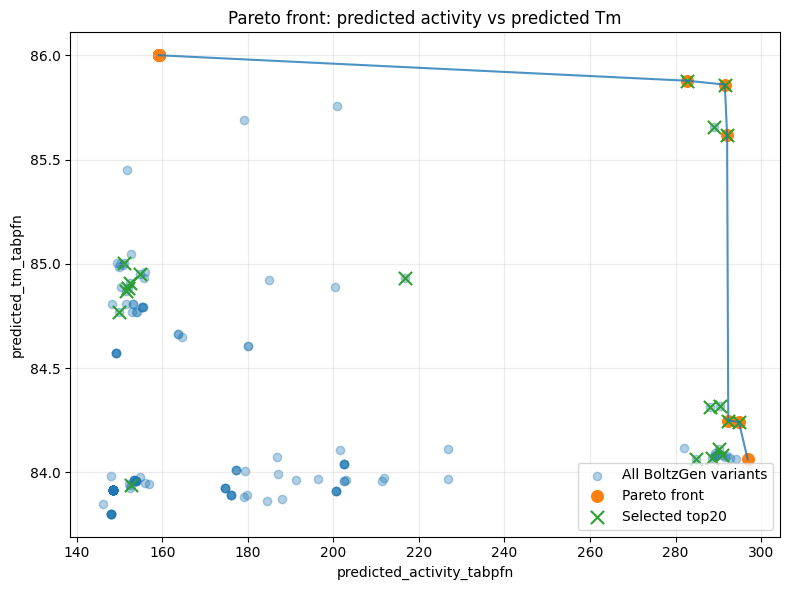

Saved Pareto plot to: /home/dwp46550/ba_nylon/results/pareto_plots/pareto_activity_vs_structure_score.png


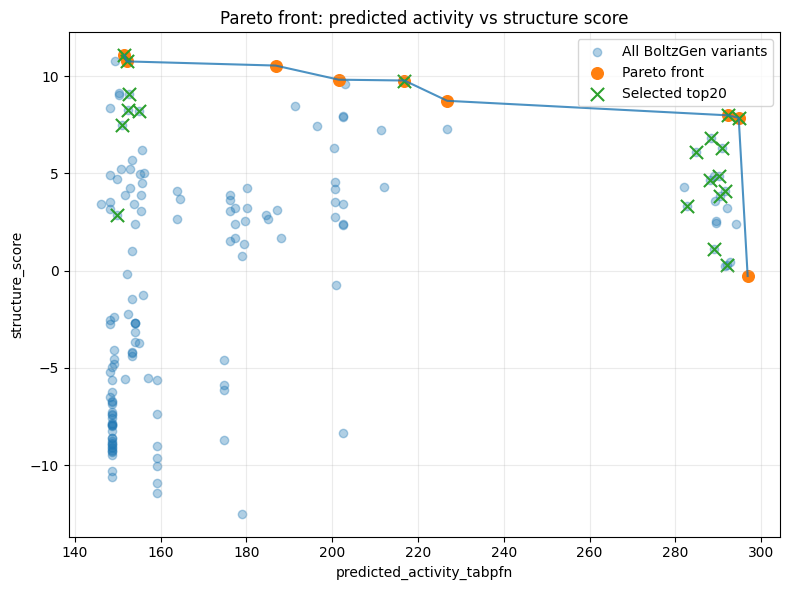

Saved Pareto plot to: /home/dwp46550/ba_nylon/results/pareto_plots/pareto_lab_score_vs_mutation_count.png


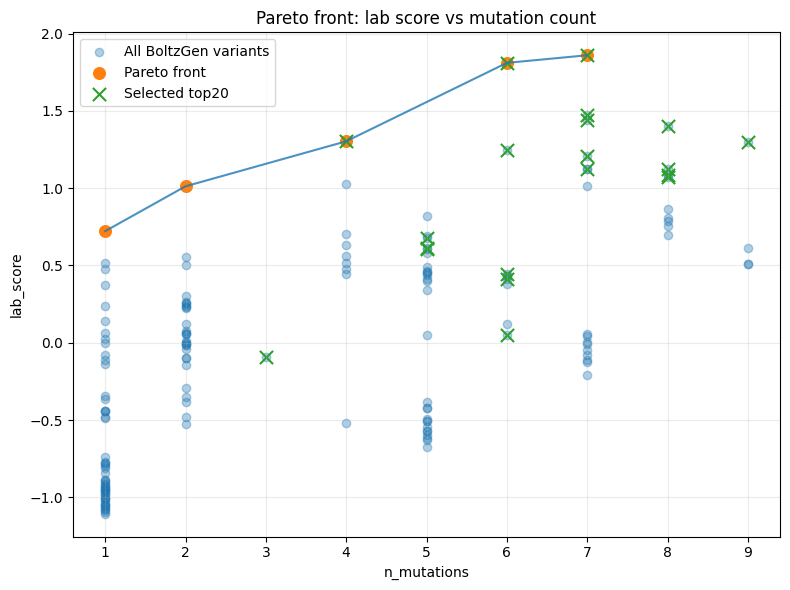

Saved Pareto plot to: /home/dwp46550/ba_nylon/results/pareto_plots/pareto_activity_vs_tm_max5.png


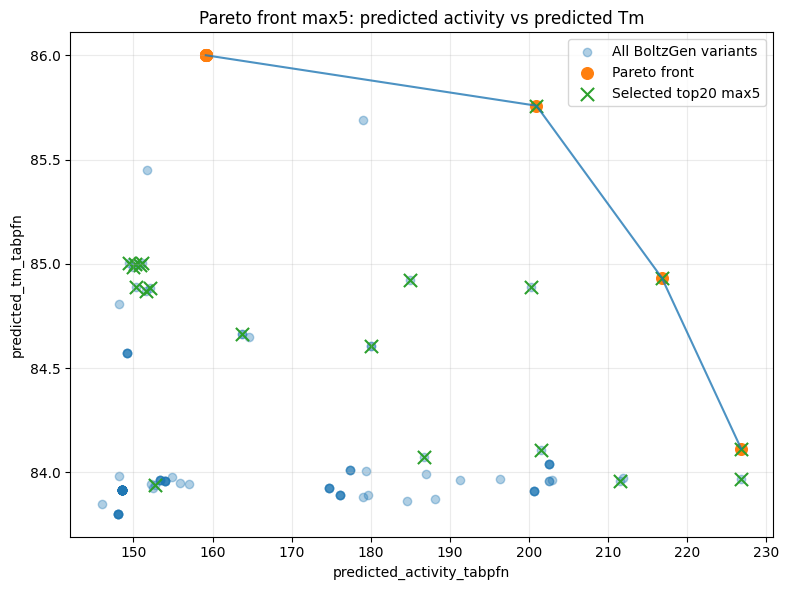

Saved Pareto plot to: /home/dwp46550/ba_nylon/results/pareto_plots/pareto_activity_vs_structure_score_max5.png


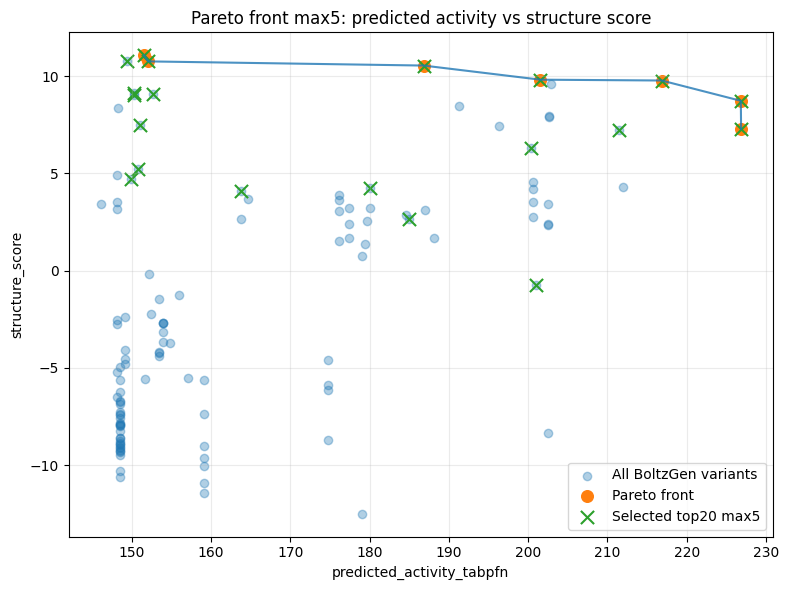


Pareto-optimal variants for predicted activity vs predicted Tm:


,variant_id,boltzgen_run,final_rank,predicted_activity_tabpfn,predicted_tm_tabpfn,structure_score,lab_score,n_mutations,mutations
18,HP_pocket__HP_pocket_27,HP_pocket,19,296.872345,84.061806,-0.280281,0.698749,8,Y98G;D99L;G111V;F134W;L137E;L139G;V144A;Y146N
0,HP_pocket__HP_pocket_09,HP_pocket,1,294.783173,84.242226,7.851806,1.475206,7,Y98S;D99S;G111Y;F134W;L137E;L139V;V144T
1,HP_pocket__HP_pocket_10,HP_pocket,2,292.315216,84.247414,7.981937,1.441356,7,Y98S;D99S;G111F;F134W;L137E;L139I;V144T
13,HP_pocket__HP_pocket_15,HP_pocket,14,292.044067,85.620430,0.286428,1.301381,9,A91G;Y98G;D99R;G111V;F134W;L137E;L139G;V144S;Y...
6,HP_pocket__HP_pocket_06,HP_pocket,7,291.510803,85.859970,4.076457,1.859352,7,Y98S;D99R;G111Y;F134W;L137E;L139I;V144T
11,HP_pocket__HP_pocket_03,HP_pocket,12,282.757355,85.878540,3.343176,1.810127,6,Y98S;D99R;G111F;F134W;L139V;V144T
49,NylC_double__NylC_double_51,NylC_double,28,159.147644,86.000702,-9.020166,0.060721,1,D99R
51,NylC_double__NylC_double_68,NylC_double,30,159.147644,86.000702,-9.620632,0.025350,1,D99R
53,NylC_double__NylC_double_52,NylC_double,32,159.147644,86.000702,-10.032824,-0.003985,1,D99R
59,NylC_double__NylC_double_79,NylC_double,38,159.147644,86.000702,-10.928869,-0.081071,1,D99R



Pareto-optimal variants for predicted activity vs structure score:


,variant_id,boltzgen_run,final_rank,predicted_activity_tabpfn,predicted_tm_tabpfn,structure_score,lab_score,n_mutations,mutations
18,HP_pocket__HP_pocket_27,HP_pocket,19,296.872345,84.061806,-0.280281,0.698749,8,Y98G;D99L;G111V;F134W;L137E;L139G;V144A;Y146N
0,HP_pocket__HP_pocket_09,HP_pocket,1,294.783173,84.242226,7.851806,1.475206,7,Y98S;D99S;G111Y;F134W;L137E;L139V;V144T
1,HP_pocket__HP_pocket_10,HP_pocket,2,292.315216,84.247414,7.981937,1.441356,7,Y98S;D99S;G111F;F134W;L137E;L139I;V144T
78,NylC_negativ__NylC_negativ_03,NylC_negativ,14,226.819962,83.967514,8.729030,0.690877,5,D99G;F134P;L137E;L139Y;V144T
68,NylC_negativ__NylC_negativ_05,NylC_negativ,4,216.825439,84.932686,9.772946,1.302965,4,F134P;L137E;L139Y;V144T
71,NylC_negativ__NylC_negativ_06,NylC_negativ,7,201.531219,84.106644,9.815171,0.634234,4,D99S;F134A;L137E;V144T
67,NylC_negativ__NylC_negativ_04,NylC_negativ,3,186.796280,84.071106,10.541944,0.517629,4,D99S;F134L;L139F;V144T
135,NylC_pocket__NylC_pocket_13,NylC_pocket,3,152.074112,84.885002,10.755605,0.676621,5,Y98S;G111Y;L137E;L139I;V144T
140,NylC_pocket__NylC_pocket_09,NylC_pocket,8,151.528549,84.871170,11.071523,0.607115,5,Y98S;G111Y;L137E;L139V;V144T



Pareto-optimal variants for lab score vs mutation count:


,variant_id,boltzgen_run,final_rank,predicted_activity_tabpfn,predicted_tm_tabpfn,structure_score,lab_score,n_mutations,mutations
101,NylC_paper__NylC_paper_10,NylC_paper,8,184.921219,84.922775,2.663567,0.722071,1,F134P
22,NylC_double__NylC_double_38,NylC_double,1,200.966721,85.758675,-0.761941,1.011939,2,D99R;F134P
68,NylC_negativ__NylC_negativ_05,NylC_negativ,4,216.825439,84.932686,9.772946,1.302965,4,F134P;L137E;L139Y;V144T
11,HP_pocket__HP_pocket_03,HP_pocket,12,282.757355,85.878540,3.343176,1.810127,6,Y98S;D99R;G111F;F134W;L139V;V144T
6,HP_pocket__HP_pocket_06,HP_pocket,7,291.510803,85.859970,4.076457,1.859352,7,Y98S;D99R;G111Y;F134W;L137E;L139I;V144T


In [15]:
# -----------------------------
# Pareto plots for BoltzGen variant ranking
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def pareto_front(df_plot, x_col, y_col, maximize_x=True, maximize_y=True):
    """
    Identify Pareto-optimal variants for two objectives.

    A variant is Pareto-optimal if no other variant is better or equal
    in both objectives and strictly better in at least one objective.
    """

    values = df_plot[[x_col, y_col]].copy()

    if not maximize_x:
        values[x_col] = -values[x_col]

    if not maximize_y:
        values[y_col] = -values[y_col]

    arr = values.to_numpy()
    is_pareto = np.ones(arr.shape[0], dtype=bool)

    for i, point in enumerate(arr):
        if not is_pareto[i]:
            continue

        dominates_i = (
            np.all(arr >= point, axis=1)
            & np.any(arr > point, axis=1)
        )

        if np.any(dominates_i):
            is_pareto[i] = False

    return is_pareto


def plot_pareto(
    df_input,
    x_col,
    y_col,
    selected_df=None,
    selected_label="selected",
    maximize_x=True,
    maximize_y=True,
    title=None,
    output_path=None,
):
    """
    Create a Pareto scatter plot for two ranking objectives.
    """

    required_cols = [x_col, y_col, "variant_id"]

    missing_cols = [
        col for col in required_cols
        if col not in df_input.columns
    ]

    if missing_cols:
        raise KeyError(f"Missing columns in df_input: {missing_cols}")

    df_plot = df_input.dropna(subset=[x_col, y_col]).copy()

    if df_plot.empty:
        raise ValueError(f"No valid data for {x_col} vs {y_col}.")

    df_plot["is_pareto"] = pareto_front(
        df_plot=df_plot,
        x_col=x_col,
        y_col=y_col,
        maximize_x=maximize_x,
        maximize_y=maximize_y,
    )

    pareto_df = (
        df_plot[df_plot["is_pareto"]]
        .sort_values(x_col, ascending=not maximize_x)
        .copy()
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        df_plot[x_col],
        df_plot[y_col],
        alpha=0.35,
        label="All BoltzGen variants",
    )

    ax.scatter(
        pareto_df[x_col],
        pareto_df[y_col],
        s=70,
        label="Pareto front",
    )

    ax.plot(
        pareto_df[x_col],
        pareto_df[y_col],
        linewidth=1.5,
        alpha=0.8,
    )

    if selected_df is not None:
        selected_ids = set(selected_df["variant_id"])

        selected_plot = df_plot[
            df_plot["variant_id"].isin(selected_ids)
        ].copy()

        if not selected_plot.empty:
            ax.scatter(
                selected_plot[x_col],
                selected_plot[y_col],
                s=90,
                marker="x",
                label=selected_label,
            )

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    if title is None:
        title = f"Pareto plot: {y_col} vs {x_col}"

    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved Pareto plot to: {output_path}")

    plt.show()

    return pareto_df


# -----------------------------
# Output directory
# -----------------------------

pareto_out_dir = project_root / "results" / "pareto_plots"
pareto_out_dir.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Pareto plot 1:
# Predicted activity vs predicted Tm
# Both should be maximized.
# -----------------------------

pareto_activity_tm = plot_pareto(
    df_input=df,
    x_col=activity_col,
    y_col=tm_col,
    selected_df=lab_top20,
    selected_label="Selected top20",
    maximize_x=True,
    maximize_y=True,
    title="Pareto front: predicted activity vs predicted Tm",
    output_path=pareto_out_dir / "pareto_activity_vs_tm.png",
)


# -----------------------------
# Pareto plot 2:
# Predicted activity vs structure score
# Both should be maximized.
# -----------------------------

pareto_activity_structure = plot_pareto(
    df_input=df,
    x_col=activity_col,
    y_col="structure_score",
    selected_df=lab_top20,
    selected_label="Selected top20",
    maximize_x=True,
    maximize_y=True,
    title="Pareto front: predicted activity vs structure score",
    output_path=pareto_out_dir / "pareto_activity_vs_structure_score.png",
)


# -----------------------------
# Pareto plot 3:
# Lab score vs number of mutations
# Lab score should be maximized, mutation count should be minimized.
# -----------------------------

pareto_labscore_mutations = plot_pareto(
    df_input=df,
    x_col="n_mutations",
    y_col="lab_score",
    selected_df=lab_top20,
    selected_label="Selected top20",
    maximize_x=False,
    maximize_y=True,
    title="Pareto front: lab score vs mutation count",
    output_path=pareto_out_dir / "pareto_lab_score_vs_mutation_count.png",
)


# -----------------------------
# Optional:
# Same plots for max5 lab list
# -----------------------------

if "lab_top20_max5" in globals():
    pareto_activity_tm_max5 = plot_pareto(
        df_input=df[df["n_mutations"] <= 5],
        x_col=activity_col,
        y_col=tm_col,
        selected_df=lab_top20_max5,
        selected_label="Selected top20 max5",
        maximize_x=True,
        maximize_y=True,
        title="Pareto front max5: predicted activity vs predicted Tm",
        output_path=pareto_out_dir / "pareto_activity_vs_tm_max5.png",
    )

    pareto_activity_structure_max5 = plot_pareto(
        df_input=df[df["n_mutations"] <= 5],
        x_col=activity_col,
        y_col="structure_score",
        selected_df=lab_top20_max5,
        selected_label="Selected top20 max5",
        maximize_x=True,
        maximize_y=True,
        title="Pareto front max5: predicted activity vs structure score",
        output_path=pareto_out_dir / "pareto_activity_vs_structure_score_max5.png",
    )


# -----------------------------
# Summary tables of Pareto-optimal variants
# -----------------------------

pareto_summary_cols = [
    "variant_id",
    "boltzgen_run",
    "final_rank",
    activity_col,
    tm_col,
    "structure_score",
    "lab_score",
    "n_mutations",
    "mutations",
]

pareto_summary_cols = [
    col for col in pareto_summary_cols
    if col in df.columns
]

pareto_activity_tm[pareto_summary_cols].to_csv(
    pareto_out_dir / "pareto_activity_vs_tm_variants.csv",
    index=False,
)

pareto_activity_structure[pareto_summary_cols].to_csv(
    pareto_out_dir / "pareto_activity_vs_structure_score_variants.csv",
    index=False,
)

pareto_labscore_mutations[pareto_summary_cols].to_csv(
    pareto_out_dir / "pareto_lab_score_vs_mutation_count_variants.csv",
    index=False,
)

print("\nPareto-optimal variants for predicted activity vs predicted Tm:")
display(pareto_activity_tm[pareto_summary_cols])

print("\nPareto-optimal variants for predicted activity vs structure score:")
display(pareto_activity_structure[pareto_summary_cols])

print("\nPareto-optimal variants for lab score vs mutation count:")
display(pareto_labscore_mutations[pareto_summary_cols])

# Detailed overview of what the code does

The workflow has six main stages.

First, the known experimental variants are converted into mutation-based features. The code reads the wild-type FASTA sequence and compares each known variant sequence against it. Each amino acid substitution is represented as a mutation string such as D304M. From these mutation strings, the code calculates global mutation descriptors such as mutation count, total charge change, hydrophobicity change, side-chain volume change, number of mutations at known positions, and number of mutations at MD-contact positions.

In the revised feature engineering step, the code also adds features designed to be useful for TabPFN. Amino acids are assigned to physicochemical groups such as small or special residues, polar uncharged residues, hydrophobic aliphatic residues, aromatic residues, positively charged residues, and negatively charged residues. The code then represents amino acid group transitions, for example negative to hydrophobic or aromatic to aromatic. It also adds position-specific descriptors for key positions such as 99, 134, 301, 304, and 330. For these positions, the code stores local charge, hydrophobicity, volume, amino acid group, and group transition information. In addition, selected biologically motivated epistasis features are included, such as D99R together with a D304 mutation, D99R together with the HP-like core, F134W together with a D304 mutation, and the HP_core combination. Concrete mutation identities and mutated positions are also one-hot encoded. This creates the feature table used for model training.

Second, the experimental labels are merged with the sequence features. The lab table is renamed so that variant ID, PA6 activity, and melting temperature have consistent column names. Activity and Tm values are converted into numeric values. The code then merges the sequence feature table with the experimental PA6 activity and thermostability labels. Constant features are removed before modeling because they contain no information for distinguishing variants.

Third, TabPFN regression models are trained. One TabPFNRegressor predicts PA6 activity, and a second TabPFNRegressor predicts melting temperature. Leave-one-out cross-validation is used because the dataset is small. The activity model shows moderate predictive performance, with LOOCV R² around 0.48, MAE around 58 activity units, and Spearman correlation around 0.66. This means the model captures a useful activity-related signal, but it should not be interpreted as a quantitatively precise activity predictor. The Tm model performs more strongly, with LOOCV R² around 0.65, MAE around 1 °C, and Spearman correlation around 0.80. This suggests that the current sequence-based features capture thermostability-related effects more reliably than activity-related effects.

Fourth, the BoltzGen results are processed. The code reads all CSV files matching all_designs_metrics_*.csv, derives a run name from each filename, and concatenates all designs into one table. The BoltzGen sequences are not full-length WT-length proteins. Instead, they are cropped or partial designed sequences that map to regions of the WT protein. Therefore, the code uses local sequence alignment against the WT sequence. Unknown residues marked as X are not treated as mutations, but are skipped during mutation calling. This prevents the complete exclusion of otherwise usable BoltzGen sequences. The alignment maps each designed fragment onto the WT coordinate system and extracts mutations such as Y98S, D99R, F134W, L137E, or V144T. The resulting table contains all BoltzGen designs, their original BoltzGen scores, run metadata, alignment coordinates, selected sequence columns, alignment quality information, and extracted mutation lists.

Fifth, the BoltzGen mutation lists are converted into the same feature space as the known experimental variants. This is done using the same feature construction function that was used for the labeled training variants. This avoids inconsistencies between the training feature representation and the prediction feature representation. The BoltzGen feature table is then aligned to the exact feature columns used during TabPFN training. Missing training columns are filled with zero, and extra BoltzGen-specific columns that were never seen during training are ignored. This is necessary because the fitted TabPFN model expects a fixed set of input columns.

Sixth, predicted activity and predicted Tm are generated for all BoltzGen variants using the trained TabPFN models. These predictions are merged back into the BoltzGen table. The predictions are used as ranking signals, not as experimentally validated activity or stability values. This distinction is important because many BoltzGen variants contain more mutations than most of the experimentally labeled variants and therefore lie partly outside the training distribution.

Finally, a balanced list of 20 laboratory candidates is selected. The final selection is not simply the top 20 by predicted activity. Instead, the workflow calculates a composite laboratory prioritization score. This score combines predicted PA6 activity, predicted Tm, BoltzGen structure quality, mutation novelty, BoltzGen rank, and penalties for low predicted Tm and high mutation count. Group A selects high composite-score candidates. Group B selects diverse and structurally acceptable variants to increase exploratory value. Group C selects structurally strong variants with medium predicted activity. This creates a lab list that balances exploitation, meaning variants predicted to perform well, with exploration, meaning variants that test informative mutation patterns.

The final selected variants are exported as a CSV file and as a FASTA file. Full-length protein sequences are reconstructed by applying the extracted BoltzGen mutations to the WT reference sequence. This produces cloneable full-length sequences for downstream experimental work.

## Modules used

The workflow uses these Python modules:

pathlib.Path is used for portable file and directory paths.

re is used to parse mutation strings and extract residue numbers from substitutions such as D304M.

pandas is used for reading CSV files, constructing DataFrames, merging tables, generating feature matrices, filtering variants, calculating summary statistics, and exporting CSV outputs.

numpy is used for numerical operations, z-score calculations, penalties, and ranking scores.

Bio.SeqIO is used to read FASTA sequences.

Bio.Align.PairwiseAligner is used for local sequence alignment between BoltzGen-designed partial sequences and the WT sequence.

sklearn.preprocessing.MultiLabelBinarizer is used to one-hot encode mutation identities, mutated positions, and amino acid group transitions.

sklearn.model_selection.LeaveOneOut is used for leave-one-out cross-validation.

sklearn.model_selection.cross_val_predict is used to generate cross-validated predictions.

sklearn.metrics.r2_score and mean_absolute_error are used to evaluate model performance.

scipy.stats.pearsonr and scipy.stats.spearmanr are used to assess linear correlation and rank correlation between measured and predicted values.

tabpfn.TabPFNRegressor is used as the small-data regression model for PA6 activity and Tm prediction.

## Where heuristics are used

Several parts of the workflow are heuristic rather than strictly learned or experimentally validated.

The amino acid property table is a simplified biochemical descriptor set. It uses manually assigned values for charge, hydrophobicity, and side-chain volume. These values are useful for representing physicochemical changes, but they do not fully describe context-dependent behavior in a folded protein. For example, histidine is assigned a partial charge, although its protonation state depends on pH and local environment.

The amino acid group assignment is also heuristic. Amino acids are grouped into broad physicochemical classes such as aromatic, hydrophobic aliphatic, polar uncharged, positive, negative, and small or special. These classes provide a compact way to represent mutation type, but the boundaries between groups are simplified. The ordinal group identifiers are mainly used as structured tabular descriptors for TabPFN, not as strict biochemical scales.

The sets known_positions = {99, 134, 301, 304, 330} and md_contact_positions = {91, 98, 111, 137, 139, 144, 146, 305} are biologically motivated feature groups. They encode prior assumptions from experimental knowledge, literature context, and MD or structural interpretation. This is useful for guiding the model, but it also biases the feature representation toward the current mechanistic hypothesis.

The selected epistasis features are heuristic. They are not learned automatically from all possible mutation combinations. Instead, they represent specific biologically motivated combinations, such as D99R with D304 mutations or D99R with the HP-like core. This is useful because the dataset is too small to support exhaustive interaction modeling, but it means that only selected interaction hypotheses are explicitly encoded.

The local sequence alignment parameters are heuristic. The workflow uses a local aligner because the BoltzGen sequences are cropped or partial sequences rather than full-length NylC sequences. The scoring parameters are suitable for mapping closely related protein fragments, but they are not uniquely determined. The alignment output should therefore be inspected using alignment coordinates, coverage, and mutation counts.

Unknown residues marked as X are ignored during mutation calling. This is a practical choice because X indicates an unknown or unresolved residue. Treating X as a real mutation would create false substitutions, while excluding the whole sequence would discard useful designs. Ignoring X positions is therefore a pragmatic compromise.

Filling missing feature columns with zero is necessary because the TabPFN model was trained on a fixed set of columns. If a training feature is absent in a BoltzGen variant, it is set to zero. Extra BoltzGen features that were never present during training are ignored. This keeps the feature space consistent but does not solve the deeper limitation that the model cannot learn direct effects for mutation types that were absent from the labeled training data.

The structure_score is heuristic. It combines z-scored BoltzGen structure metrics, adding metrics where higher is considered better and subtracting metrics where lower is considered better. The directionality is plausible, but the weights are not experimentally learned.

The novelty_score is heuristic. It rewards variants containing mutations at rarer positions. This is useful for exploratory candidate selection, but it does not directly measure biochemical novelty or functional plausibility.

The mutation_count_penalty is heuristic. It penalizes variants with many mutations because highly mutated variants are farther from the experimentally labeled training space and therefore have more uncertain predictions. This does not mean that highly mutated variants are necessarily bad. It only reflects increased model extrapolation risk.

The tm_penalty is heuristic. It penalizes variants below a chosen predicted Tm threshold. The threshold is used to avoid prioritizing variants that may be unstable, but it is not an experimentally validated cutoff.

The final lab_score is a heuristic decision score. It combines predicted activity, predicted Tm, structure quality, novelty, mutation count, BoltzGen rank, and thermostability penalty. It is not a trained model and should not be interpreted as a calibrated probability of experimental success. It is a practical prioritization score for selecting a limited number of laboratory variants.

The group selection strategy is heuristic but scientifically defensible. Group A prioritizes variants with high composite scores. Group B increases diversity by selecting unusual but structurally acceptable mutation patterns. Group C tests whether strong structure-based scores can identify useful candidates that are not top-ranked by predicted activity alone. This makes the final lab list more informative than a simple top-20 activity ranking.
